<div style="border: 2px solid; color: rgba(255, 255, 255, 0.8); padding: 10px; border-radius: 8px;">


# Fish Mercury Analysis

### Predicting Mercury Levels in Alberta Fish Using Machine Learning

This project analyzes mercury concentrations in fish from Alberta waterbodies and applies data preprocessing, feature engineering, exploratory data analysis, and supervised machine learning techniques to predict mercury levels.
<br><br>


<span style="color:  rgba(255, 255, 255, 0.8);">
<span style="color: rgba(255, 255, 255, 0.8); font-size: 18px;text-decoration: underline">Project Summary:</span><br><br>
    - Data File: "hg-in-fish_ah-1997-2021_march2024xlsx.xlsx"<br>
    - Description:   Fish samples from Alberta Waterbodies recording mercury levels in fish. This project applies supervised machine learning techniques, supported by data preprocessing and feature engineering, to predict mercury levels in fish.<br>

<span style="color: rgba(255, 255, 255, 0.8); font-size: 18px;text-decoration: underline">Table of Contents:</span><br>
- Section 1 - Get Working Data<br>
- Section 2 - Clean the Data<br>
- Section 3 - Impute Missing Values<br>
- Section 4 - Feature Engineering<br>
- Section 5 - Examine Clean Data<br>
- Section 6 - Simple Linear Model<br>
- Section 7 - Explore Other Models<br><br>
    - Model A - Linear Regresssion - All features<br>
    - Model B - Linear Regression - Feature Selection<br>
    - Model C - Random Forest Regressor<br>
    - Model D - Light GBM Gradient Boosting<br><br>
- Section 8 - Conclusion<br>
</span>


</div>

<div style="border: 2px solid; color: rgba(255, 255, 255, 0.8); padding: 10px; border-radius: 8px;">

This project uses color coded boxes for organization.

Below is what the box colors represent

</span>

<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px;">
<span style="color: #7FDBFF; font-size:14px">
  Blue Boxes - Section Headers
</span>
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen; font-size:14px">Green Boxes - Sub-Section Headers</span>
</div>

<div style="border: 2px solid orange; padding: 10px; border-radius: 8px;">
<span style="color: orange; text-decoration;font-size:14px">Orange Boxes - Miscellaneous Comments</span>
</div>


<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">
<span style="color: #ff8e8e; text-decoration;font-size:14px">Red Boxes - Plot Analysis</span>
</div>


<div style="border: 2px solid yellow; padding: 10px; border-radius: 8px;">
<span style="color: yellow;font-size:14px">Yellow Boxes - Model Testing </span>

<br><br>
<hr style="border: none; height: 4px; background-color: rgba(255,255,255,0.6); border-radius: 2px;">
<br><br>

<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px; font-size: 30px">
<span style="color: #7FDBFF;">
  Section 1 - Get Working Data
</span>
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen;">Sub-Section 1: - Import Libraries</span>
</div>

In [1]:
# Import needed libraries

import numpy as np
import pandas as pd
import seaborn as sns
import itertools
import random
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import jarque_bera, normaltest
#
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import KFold, cross_validate, cross_val_predict, cross_val_score
#
from lightgbm import LGBMRegressor


<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen;">Sub-Section 2: - Get Base File and Make Working Copy</span>
</div>

In [2]:
# Get the base file
fishBase = pd.read_excel('hg-in-fish_ah-1997-2021_march2024xlsx.xlsx')

# Make a working copy
fish = fishBase.copy()

# See the general info
#   - notice that many fields are 'object' types
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 7004 entries, 0 to 7003
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Program_ID               7004 non-null   str           
 1   Sample_ID                7004 non-null   object        
 2   Collection Date          7004 non-null   datetime64[us]
 3   Date_flag                7004 non-null   object        
 4   Waterbody Name           7004 non-null   str           
 5   Waterbody Type           7004 non-null   str           
 6   Latitude                 7004 non-null   object        
 7   Longitude                7004 non-null   object        
 8   Land Use Region          7004 non-null   str           
 9   FWMIS ID                 7004 non-null   object        
 10  Species Code             7004 non-null   str           
 11  Common Name              7004 non-null   str           
 12  Binomial Name            7004 non-null   str 

<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px; font-size: 30px">
<span style="color: #7FDBFF;">
  Section 2 - Clean the Data
</span>
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen;">Sub-Section 3: - Cleanup Titles and Examine file</span>
</div>

In [3]:
# Cleanup the titles

# Remove spaces from column names
fish.columns = fish.columns.str.replace(' ','')

# Remove brackets from names (e.g. Age(years))
fish.columns = fish.columns.str.split('(').str[0]

fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 7004 entries, 0 to 7003
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Program_ID              7004 non-null   str           
 1   Sample_ID               7004 non-null   object        
 2   CollectionDate          7004 non-null   datetime64[us]
 3   Date_flag               7004 non-null   object        
 4   WaterbodyName           7004 non-null   str           
 5   WaterbodyType           7004 non-null   str           
 6   Latitude                7004 non-null   object        
 7   Longitude               7004 non-null   object        
 8   LandUseRegion           7004 non-null   str           
 9   FWMISID                 7004 non-null   object        
 10  SpeciesCode             7004 non-null   str           
 11  CommonName              7004 non-null   str           
 12  BinomialName            7004 non-null   str           
 13 

In [4]:
# Check for duplicates
#
#   - Result -> No duplicates

duplicate_rows_data = fish[fish.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (0, 25)


In [5]:
# Examine unique values

for column in fish.columns:
    num_distinct_values = len(fish[column].unique())
    print(f"{column:<25}- {num_distinct_values} distinct values")

Program_ID               - 7004 distinct values
Sample_ID                - 6968 distinct values
CollectionDate           - 320 distinct values
Date_flag                - 3 distinct values
WaterbodyName            - 144 distinct values
WaterbodyType            - 5 distinct values
Latitude                 - 157 distinct values
Longitude                - 157 distinct values
LandUseRegion            - 8 distinct values
FWMISID                  - 131 distinct values
SpeciesCode              - 24 distinct values
CommonName               - 24 distinct values
BinomialName             - 24 distinct values
Sex                      - 3 distinct values
ForkLength               - 766 distinct values
ForkLengthMeasurement    - 3 distinct values
TotalLength              - 808 distinct values
TotalLengthMeasurement   - 4 distinct values
LengthEstimateFactor     - 2 distinct values
Weight                   - 2410 distinct values
WeightMeasurement        - 4 distinct values
Maturity                 - 4 

In [6]:
# See a sampling of the unique fields
fish.apply(pd.unique)

Program_ID                [21-FM-LKWH-01, 21-FM-LKWH-02, 21-FM-LKWH-03, ...
Sample_ID                 [21-FM-LKWH-01, 21-FM-LKWH-02, 21-FM-LKWH-03, ...
CollectionDate            [2021-09-28T00:00:00.000000, 2021-09-29T00:00:...
Date_flag                                                   [0, Unknown, 1]
WaterbodyName             [40 Mile Reservoir, Amisk Lake, Angling Lake, ...
WaterbodyType              [Reservoir, Lake, River, Canal, Stormwater Pond]
Latitude                  [49.64363, 54.597508, 54.200853, 52.74685, 53....
Longitude                 [-111.393672, -112.636283, -110.327966, -110.5...
LandUseRegion             [South Saskatchewan, Upper Athabasca, Lower At...
FWMISID                   [6813, 3916, 3920, 3938, 1968, 3969, 3994, 400...
SpeciesCode               [LKWH, NRPK, WALL, MNWH, YLPR, PRCR, BNTR, LNS...
CommonName                [Lake Whitefish, Northern Pike, Walleye, Mount...
BinomialName              [Coregonus clupeaformis, Esox lucius, Stizoste...
Sex         

In [8]:
# See if any null values

print(fish.isnull().sum())

Program_ID                   0
Sample_ID                    0
CollectionDate               0
Date_flag                    0
WaterbodyName                0
WaterbodyType                0
Latitude                     0
Longitude                    0
LandUseRegion                0
FWMISID                      0
SpeciesCode                  0
CommonName                   0
BinomialName                 0
Sex                          0
ForkLength                   0
ForkLengthMeasurement     1082
TotalLength                  0
TotalLengthMeasurement    1199
LengthEstimateFactor      7002
Weight                       0
WeightMeasurement          137
Maturity                     0
Age                       1588
AgingStructure            1588
Hg                           0
dtype: int64


<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen;">Sub-Section 4: - Drop uneeded columns and convert data types</span>
</div>

In [9]:
# Lets drop the following columns:
#
# Program_ID, Sample_ID - the ids are not used
# Latitude, Longitude, FWMISID - we will use WaterbodyName and LandUseRegion for location info
# SpeciesCode, BinoimialName - we will use the more descriptive CommonName to identify the species
# ForkLengthMeasurement, TotalLengthMeasurement - these are Field, Lab, Unknown, nan - not concerned where fish was measured
# TotalLength - highly correlated to ForkLenght so will just keep ForkLength as my Length field
# LengthEstimateFactor - its all nan, no value to us
# WeightMeasurement - these are Field, Lab, Unknown, nan - not concerned where fish was weighed
# Aging Structure - this relates to how the fish's age was determined, it doesnt help us determine the age

fish = fish.drop(['Program_ID','Sample_ID','Date_flag','Latitude','Longitude','FWMISID','SpeciesCode','BinomialName','ForkLengthMeasurement','TotalLengthMeasurement', 'TotalLength','LengthEstimateFactor','WeightMeasurement','AgingStructure'], axis=1)

In [10]:
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 7004 entries, 0 to 7003
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CollectionDate  7004 non-null   datetime64[us]
 1   WaterbodyName   7004 non-null   str           
 2   WaterbodyType   7004 non-null   str           
 3   LandUseRegion   7004 non-null   str           
 4   CommonName      7004 non-null   str           
 5   Sex             7004 non-null   str           
 6   ForkLength      7004 non-null   object        
 7   Weight          7004 non-null   object        
 8   Maturity        7004 non-null   str           
 9   Age             5416 non-null   object        
 10  Hg              7004 non-null   object        
dtypes: datetime64[us](1), object(4), str(6)
memory usage: 602.0+ KB


In [11]:
fish.head(5)

,CollectionDate,WaterbodyName,WaterbodyType,LandUseRegion,CommonName,Sex,ForkLength,Weight,Maturity,Age,Hg
0,2021-09-28,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,383,610,Mature,Unknown,0.136
1,2021-09-28,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,370,647,Mature,9,0.104
2,2021-09-28,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Male,374,710,Mature,6,0.057
3,2021-09-28,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,355,591,Mature,Unknown,0.082
4,2021-09-28,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,347,600,Mature,9,0.143


In [12]:
# Modify the Data types

# Lets convert our string fields to category 
categorical_cols = ['WaterbodyName', 'WaterbodyType', 'LandUseRegion', 'CommonName', 'Sex', 'Maturity']
for col in categorical_cols:
    fish[col] = fish[col].astype('category')
    
# Lets convert our numeric fields from object to numeric  
numeric_cols = ['ForkLength', 'Weight', 'Age', 'Hg']  # replace with your columns
for col in numeric_cols:
    fish[col] = pd.to_numeric(fish[col], errors='coerce')

In [13]:
fish.info()

<class 'pandas.DataFrame'>
RangeIndex: 7004 entries, 0 to 7003
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   CollectionDate  7004 non-null   datetime64[us]
 1   WaterbodyName   7004 non-null   category      
 2   WaterbodyType   7004 non-null   category      
 3   LandUseRegion   7004 non-null   category      
 4   CommonName      7004 non-null   category      
 5   Sex             7004 non-null   category      
 6   ForkLength      5921 non-null   float64       
 7   Weight          6867 non-null   float64       
 8   Maturity        7004 non-null   category      
 9   Age             3332 non-null   float64       
 10  Hg              6998 non-null   float64       
dtypes: category(6), datetime64[us](1), float64(4)
memory usage: 323.1 KB


<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen;">Sub-Section 5: - Examine Date, Maturity, and Age fields</span>
</div>

Unique Days:  320
Oldest Date:  1997-07-21 00:00:00
Newest Date:  2023-09-15 00:00:00


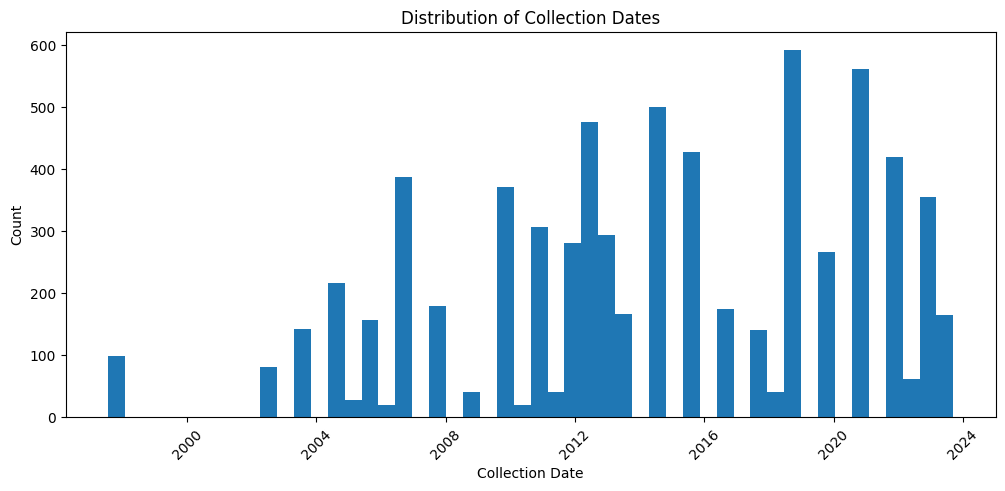

In [14]:
# Examine Date field

# Review our Date field
dates = pd.to_datetime(fish['CollectionDate'])
print("Unique Days: ", dates.dt.date.nunique())
print("Oldest Date: ", dates.min())
print("Newest Date: ", dates.max())

plt.figure(figsize=(12,5))
plt.hist(dates.dropna(), bins=50)  # drop NaN values
plt.xlabel("Collection Date")
plt.ylabel("Count")
plt.title("Distribution of Collection Dates")
plt.xticks(rotation=45)
plt.show()

In [15]:
# Interesting to see the distribution of dates
# We are not doing a time series analysis so we will drop the CollectionDate field

fish = fish.drop(['CollectionDate'], axis=1)

In [16]:
# Lets examine the Age related fields, Maturity and Age

# Count rows where both Age and Maturity are NaN
# Count rows where both Age and Maturity are "Unknown"
num_both_unknown = fish[(fish['Age'] == 'Unknown') & (fish['Maturity'] == 'Unknown')].shape[0]
print("Rows where both Age and Maturity are 'Unknown':", num_both_unknown)

# Count rows where Age is NaN or "Unknown"
num_missing_age = fish[(fish['Age'].isnull()) | (fish['Age'] == 'Unknown')].shape[0]
print("Rows where Age is missing or Unknown:", num_missing_age)

# Count rows where Age is NaN or "Unknown"
num_missing_maturity = fish[(fish['Maturity'].isnull()) | (fish['Maturity'] == 'Unknown')].shape[0]
print("Rows where Maturity is missing or Unknown:", num_missing_maturity)

# Count rows where Age is missing/Unknown AND Maturity is missing/Unknown
num_both_missing_or_unknown = fish[
    ((fish['Age'].isnull()) | (fish['Age'] == 'Unknown')) &
    ((fish['Maturity'].isnull()) | (fish['Maturity'] == 'Unknown'))
].shape[0]

print("Rows where Maturity & Age are both missing or Unknown:", num_both_missing_or_unknown)

Rows where both Age and Maturity are 'Unknown': 0
Rows where Age is missing or Unknown: 3672
Rows where Maturity is missing or Unknown: 2591
Rows where Maturity & Age are both missing or Unknown: 2569


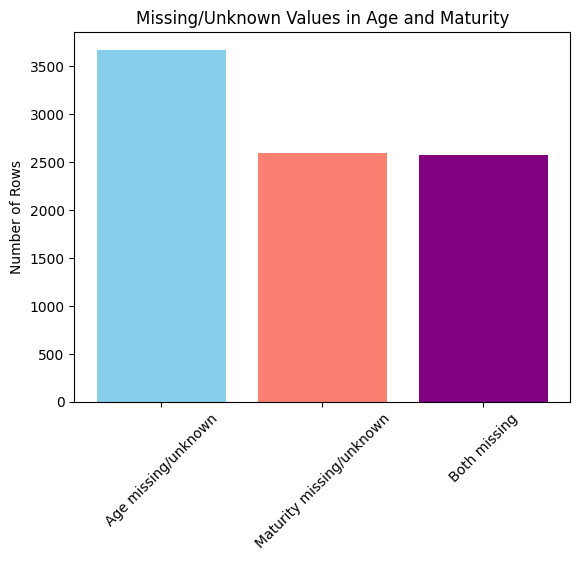

In [17]:
# See the Missing / NaN Maturity and Age values in a plot

# Counts
num_age_missing = fish['Age'].isnull().sum() + (fish['Age'] == 'Unknown').sum()
num_maturity_missing = fish['Maturity'].isnull().sum() + (fish['Maturity'] == 'Unknown').sum()

both_missing = fish[
    ((fish['Age'].isnull()) | (fish['Age'] == 'Unknown')) &
    ((fish['Maturity'].isnull()) | (fish['Maturity'] == 'Unknown'))
].shape[0]

# Create a simple bar plot
plt.bar(['Age missing/unknown', 'Maturity missing/unknown', 'Both missing'], 
        [num_age_missing, num_maturity_missing, both_missing], color=['skyblue', 'salmon', 'purple'])

plt.ylabel("Number of Rows")
plt.title("Missing/Unknown Values in Age and Maturity")
plt.xticks(rotation=45)
plt.show()

In [18]:
# Replace the Maturity NaN's with "Unknown" 
# Unknown becomes a valid category for the Maturity column, we'll use it when we try to fill in missing Age values

fish['Maturity'] = fish['Maturity'].astype('category')
fish['Maturity'] = fish['Maturity'].fillna('Unknown')  # add 'Unknown' as category

In [19]:
# Check for duplicates
#
#   - Result -> 6 Duplicates after we filled in Maturity as "Unknown"
#            -> Ok to keep these

duplicate_rows_data = fish[fish.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (6, 10)


In [20]:
fish.head()


,WaterbodyName,WaterbodyType,LandUseRegion,CommonName,Sex,ForkLength,Weight,Maturity,Age,Hg
0,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,383.0,610.0,Mature,NaN,0.136
1,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,370.0,647.0,Mature,9.0,0.104
2,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Male,374.0,710.0,Mature,6.0,0.057
3,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,355.0,591.0,Mature,NaN,0.082
4,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,347.0,600.0,Mature,9.0,0.143


<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px; font-size: 30px">
<span style="color: #7FDBFF;">
  Section 3 - Impute Missing Values
</span>
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen;">Sub-Section 6: - Handle the missing values</span>
</div>

In [21]:
#Check on my nans
print(fish.isnull().sum())

WaterbodyName       0
WaterbodyType       0
LandUseRegion       0
CommonName          0
Sex                 0
ForkLength       1083
Weight            137
Maturity            0
Age              3672
Hg                  6
dtype: int64


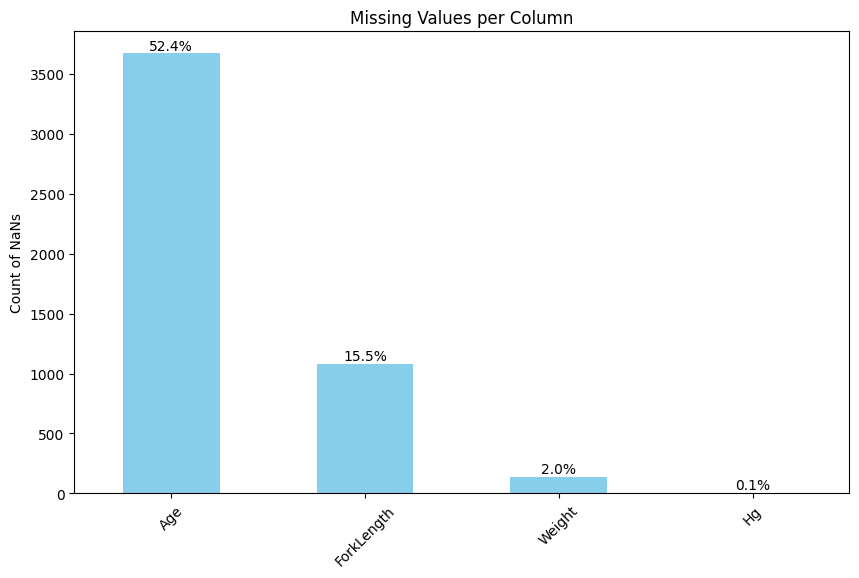

In [22]:
# Show Missing values in a plot along with %

# Count missing
missing = fish.isnull().sum()

# Ensure it's a clean Series
missing = pd.Series(missing.values, index=fish.columns)

# Filter only columns with missing values
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values")
else:
    # Calculate percentages
    total_rows = len(fish)
    percentages = missing / total_rows * 100

    # Plot
    plt.figure(figsize=(10,6))
    bars = missing.sort_values(ascending=False).plot(kind='bar', color='skyblue')

    # Add % labels on top of bars
    for bar, pct in zip(bars.patches, percentages[missing.sort_values(ascending=False).index]):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 5, f"{pct:.1f}%", 
                 ha='center', va='bottom')

    plt.title("Missing Values per Column")
    plt.ylabel("Count of NaNs")
    plt.xticks(rotation=45)
    plt.show()

In [23]:
# Drop the 6 rows in fish where there is NaN for Hg
fish = fish.dropna(subset=['Hg'])

In [24]:
# Fill in Missing values for Forklength and Weight

# Since Weight NaNs is small (2%) lets fill thouse with median values
# ForkLength NaNs is larger (15%) -- Since it's < 20% its ok to keep using, I will use median for those also

fish['ForkLength'] = fish['ForkLength'].fillna(fish['ForkLength'].median())
fish['Weight'] = fish['Weight'].fillna(fish['Weight'].median())

In [25]:
# Check for duplicates again
#
#   - Result -> No new duplicates beyond the 6 that there were there already

duplicate_rows_data = fish[fish.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (6, 10)


In [26]:
#Check again on nans
print(fish.isnull().sum())

WaterbodyName       0
WaterbodyType       0
LandUseRegion       0
CommonName          0
Sex                 0
ForkLength          0
Weight              0
Maturity            0
Age              3668
Hg                  0
dtype: int64


In [27]:
fish.info()

<class 'pandas.DataFrame'>
Index: 6998 entries, 0 to 7003
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   WaterbodyName  6998 non-null   category
 1   WaterbodyType  6998 non-null   category
 2   LandUseRegion  6998 non-null   category
 3   CommonName     6998 non-null   category
 4   Sex            6998 non-null   category
 5   ForkLength     6998 non-null   float64 
 6   Weight         6998 non-null   float64 
 7   Maturity       6998 non-null   category
 8   Age            3330 non-null   float64 
 9   Hg             6998 non-null   float64 
dtypes: category(6), float64(4)
memory usage: 322.8 KB


In [28]:
# Before we fill in the missing Ages, lets Make a copy to revert to in case
fish_preAgeAdjust = fish.copy()

In [29]:
# Let's see the standard deviation of the Ages before we predict the missing values

age_std_before = fish['Age'].std()
print(f"Standard deviation of Age (ignoring missing values): {age_std_before:.3f}")

Standard deviation of Age (ignoring missing values): 4.689


In [30]:
# Age Prediction ***

# Lets use Random Forest and target encoding in our method to populate all of the missing ages in Age column
#
# We'll create a column called Waterbody_age_mean to hold avg age by WaterbodyName
# We will then include that feature among the set of features, to perform Random Tree modeling to calculate missing Age values
#
# We will loop through all possible combinations of features to find the combination that produces the lowest Root Mean Squared Error


# Step 1 - Compute Waterbody mean age
train_temp = fish[~fish['Age'].isnull()].copy()  # only rows with Age
waterbody_age_means = train_temp.groupby('WaterbodyName')['Age'].mean() #Group them by waterbodyname and then calculate mean for Age column
fish['Waterbody_age_mean'] = fish['WaterbodyName'].map(waterbody_age_means) #Map the mean ages back to the dataframe
fish['Waterbody_age_mean'] = fish['Waterbody_age_mean'].fillna(train_temp['Age'].mean()) #use global Age mean to fill the rows where waterbodyname has no mean

# Step 2 - Split known vs unknown Age
train = fish[~fish['Age'].isnull()].copy()
predict = fish[fish['Age'].isnull()].copy()

fish['Age_imputed'] = fish['Age'].isnull() # Flag imputed rows BEFORE filling


# Step 3 - Feature setup
all_features = ['ForkLength','Weight','Sex','CommonName','Maturity','Waterbody_age_mean']
cat_cols = ['Sex','CommonName','Maturity']
num_cols = ['ForkLength','Weight','Waterbody_age_mean']

# Step 4 - Loop through feature combinations
results = []

for r in range(1, len(all_features)+1):
    for combo in itertools.combinations(all_features, r):
        selected = list(combo)
        cat = [c for c in selected if c in cat_cols]
        num = [c for c in selected if c in num_cols]

        # Preprocessing pipeline
        preprocessor = ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
            ('num', 'passthrough', num)
        ])

        # Full pipeline with model
        model = Pipeline([
            ('prep', preprocessor),
            ('rf', RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            ))
        ])

        X = train[selected]
        y = train['Age'].astype(float)

        # 5-fold CV RMSE
        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring='neg_root_mean_squared_error'
        )

        rmse_mean = -scores.mean()
        rmse_std = abs(scores.std() ) 
        #results.append((selected, rmse))
        results.append((selected, rmse_mean, rmse_std))

results = sorted(results, key=lambda x: x[1]) # Sort by RMSE

# Show top 10 feature combinations
print("Top 10 feature combinations by RMSE (mean ± std):")
for selected, mean_rmse, std_rmse in sorted(results, key=lambda x: x[1])[:10]:
    print(f"{selected} → {mean_rmse:.3f} ± {std_rmse:.3f}")
    

# Step 5 - Fit model with best features
best_features = results[0][0]  # best combo
cat_best = [c for c in best_features if c in cat_cols]
num_best = [c for c in best_features if c in num_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_best),
    ('num', 'passthrough', num_best)
])

final_model = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on all known data
X_train = train[best_features]
y_train = train['Age'].astype(float)
final_model.fit(X_train, y_train)

# Step 6 - Predict missing Ages
X_predict = predict[best_features]
predicted_ages = final_model.predict(X_predict)

# Fill missing Ages
fish.loc[fish['Age'].isnull(), 'Age'] = predicted_ages

# Step 7 - Print Summary
print("Age after imputation:")
print(fish['Age'].describe())
print("Number of imputed rows:", fish['Age_imputed'].sum())

Top 10 feature combinations by RMSE (mean ± std):
['ForkLength', 'Weight', 'Sex', 'CommonName', 'Maturity', 'Waterbody_age_mean'] → 3.406 ± 0.338
['ForkLength', 'Weight', 'Sex', 'CommonName', 'Waterbody_age_mean'] → 3.454 ± 0.351
['ForkLength', 'Weight', 'CommonName', 'Maturity', 'Waterbody_age_mean'] → 3.462 ± 0.339
['ForkLength', 'Weight', 'CommonName', 'Waterbody_age_mean'] → 3.532 ± 0.379
['ForkLength', 'Sex', 'CommonName', 'Maturity', 'Waterbody_age_mean'] → 3.548 ± 0.346
['Weight', 'Sex', 'CommonName', 'Maturity', 'Waterbody_age_mean'] → 3.588 ± 0.356
['ForkLength', 'Sex', 'CommonName', 'Waterbody_age_mean'] → 3.611 ± 0.373
['ForkLength', 'CommonName', 'Maturity', 'Waterbody_age_mean'] → 3.629 ± 0.369
['Weight', 'CommonName', 'Maturity', 'Waterbody_age_mean'] → 3.649 ± 0.362
['Weight', 'Sex', 'CommonName', 'Waterbody_age_mean'] → 3.655 ± 0.370
Age after imputation:
count    6998.00000
mean        7.69052
std         4.03303
min         0.00000
25%         5.00000
50%         7.00

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Age Prediction Modeling
</span>

<br><br>

<span style="color: #a9f0b3; font-size: 18px; text-decoration: underline;">
Random Forest Model
</span>
<br><br>


<span style="color: #e7eff0; font-size: 16px;">

Engineer a biologically meaningful feature --> average age per waterbody (captures “typical age of fish in that lake/river” and adds environmental context).<br>
Treats Age as a regression problem --> predict continuous Age values from fish traits
- Train model using rows where Age is known
- Predict rows where Age is missing
Uses exhaustive feature selection --> try every feature subset
- Loop over every possible subset of features
- For each subset we are doing the following:
    - Build a preprocessing and model pipeline
    - OneHotEncode categorical features
    - Pass numeric features directly
    - Train a Random Forest regressor
Validates properly with cross-validation --> avoids single train/test bias, using brute-force feature selection with 5-fold CV and evaluating performance using RMSE (prediction error)
Uses best model to impute missing values --> replace missing Age values with model predictions (continuous estimates instead of labels)


<span style="color: #d2b075; font-size: 18px;text-decoration: underline">Results:</span><br><br>

Best Feature Combo RMSE:   3.406<br><br>
Using features:<br><br>- ForkLength<br>- Weight<br>- Sex<br>- CommonName<br>- Maturity<br>- Waterbody_age_mean<br><br>


It's decent in that it is <  standard deviation of the ages before we impute them (3.406 < 4.689). 

Approximate R_Squared is 1 - (RMSE^2 / variance). In our case its (1 - (3.406^2)/(4.689^2)) = 0.472   ===> Our Model explains about 47% of the variance in Ages which is ok.

We're capturing real signal from our features. </span>
</div>



In [31]:
# Lets examine the Sex field
fish['Sex'].value_counts(normalize=True)

Sex
Female     0.424979
Male       0.310660
Unknown    0.264361
Name: proportion, dtype: float64

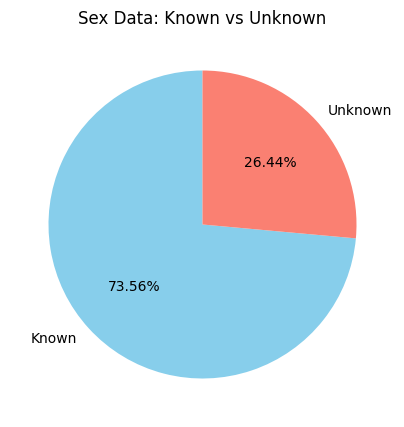

In [32]:
# Lets see what % of the sex column is unknown --> (26.44%)
#
# Result is 26% -- thats alot

pct_unknown = (fish['Sex'] == 'Unknown').mean() * 100
pct_known = 100 - pct_unknown

plt.figure(figsize=(5,5))
plt.pie([pct_known, pct_unknown],
        labels=['Known', 'Unknown'],
        autopct='%1.2f%%',
        colors=['skyblue', 'salmon'],
        startangle=90)
plt.title("Sex Data: Known vs Unknown")
plt.show()

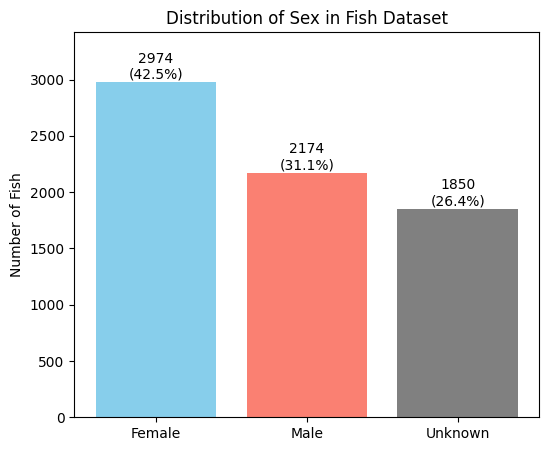

In [34]:
# Lets see the the distribution of values that are in the Sex column

# Get counts and percentages
sex_counts = fish['Sex'].value_counts()
total = sex_counts.sum()
sex_pct = sex_counts / total * 100

plt.figure(figsize=(6,5))
bars = plt.bar(sex_counts.index, sex_counts.values, color=['skyblue', 'salmon', 'gray'])

# Increase y-limit to make room for labels
plt.ylim(0, sex_counts.values.max() * 1.15)  # 15% extra space on top

# Add count and % labels on top of each bar
for bar, pct in zip(bars, sex_pct):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f"{height}\n({pct:.1f}%)",
             ha='center', va='bottom')

plt.ylabel("Number of Fish")
plt.title("Distribution of Sex in Fish Dataset")
plt.show()

In [35]:
# Create a backup in case we need to revert while doing Sex modeling
fish_preSex = fish.copy()

In [ ]:
# Sex Prediction Modeling

# Lets model the Sex column in the same way as Age above to fill in the missing Sex values.

# Step 1 - Compute Waterbody mean age
train_temp = fish[~fish['Age'].isnull()].copy()

# While we calculated Waterbody_age_mean earlier when we imputed Ages, we run it again because now blank Age fields are populated
waterbody_age_means = train_temp.groupby('WaterbodyName')['Age'].mean()
fish['Waterbody_age_mean'] = fish['WaterbodyName'].map(waterbody_age_means)
fish['Waterbody_age_mean'] = fish['Waterbody_age_mean'].fillna(train_temp['Age'].mean())


# Step 2 - Split known vs unknown Sex
train = fish[fish['Sex'] != 'Unknown'].copy()
predict = fish[fish['Sex'] == 'Unknown'].copy()

fish['Sex_imputed'] = fish['Sex'] == 'Unknown'


# Step 3 - Feature setup
all_features = ['ForkLength','Weight','CommonName','Maturity','Waterbody_age_mean','Age']

cat_cols = ['CommonName','Maturity']
num_cols = ['ForkLength','Weight','Waterbody_age_mean','Age']


# Step 4 - Loop through feature combinations
results = []

for r in range(1, len(all_features)+1):
    for combo in itertools.combinations(all_features, r):
        selected = list(combo)

        cat = [c for c in selected if c in cat_cols]
        num = [c for c in selected if c in num_cols]

        preprocessor = ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
            ('num', 'passthrough', num)
        ])

        model = Pipeline([
            ('prep', preprocessor),
            ('rf', RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1,
                class_weight='balanced'
            ))
        ])

        X = train[selected]
        y = train['Sex']

        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring='accuracy'
        )

        acc_mean = scores.mean()
        acc_std = scores.std()

        results.append((selected, acc_mean, acc_std))


# Step 5 - Sort + display results
results = sorted(results, key=lambda x: x[1], reverse=True)

print("Top 10 feature combinations by Accuracy (mean ± std):")
for selected, mean_acc, std_acc in results[:10]:
    print(f"{selected} → {mean_acc:.3f} ± {std_acc:.3f}")


# Step 6 - Train final model (best features)
best_features, best_acc, best_std = results[0]

cat_best = [c for c in best_features if c in cat_cols]
num_best = [c for c in best_features if c in num_cols]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_best),
    ('num', 'passthrough', num_best)
])

final_model = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# Train on all known Sex data
X_train = train[best_features]
y_train = train['Sex']
final_model.fit(X_train, y_train)


# Step 7 - Predict missing Sex
X_predict = predict[best_features]
predicted_sex = final_model.predict(X_predict)

fish.loc[fish['Sex'] == 'Unknown', 'Sex'] = predicted_sex


# Step 8 - Summary
print("\n===== MODEL SUMMARY =====")
print(f"Best features: {best_features}")
print(f"Cross-validated Accuracy: {best_acc:.3f} ± {best_std:.3f}")

print("\nSex distribution after imputation:")
print(fish['Sex'].value_counts())

print("\nNumber of imputed rows:", fish['Sex_imputed'].sum())

Top 10 feature combinations by Accuracy (mean ± std):
['ForkLength', 'Weight', 'CommonName', 'Maturity', 'Age'] → 0.625 ± 0.020
['ForkLength', 'Weight', 'CommonName', 'Maturity', 'Waterbody_age_mean', 'Age'] → 0.621 ± 0.017
['ForkLength', 'Weight', 'Maturity', 'Age'] → 0.618 ± 0.006
['ForkLength', 'CommonName', 'Maturity', 'Waterbody_age_mean', 'Age'] → 0.617 ± 0.016
['ForkLength', 'Weight', 'Maturity', 'Waterbody_age_mean', 'Age'] → 0.611 ± 0.034
['ForkLength', 'Weight', 'CommonName', 'Waterbody_age_mean', 'Age'] → 0.601 ± 0.026
['ForkLength', 'Weight', 'Age'] → 0.599 ± 0.009
['ForkLength', 'Weight', 'Waterbody_age_mean', 'Age'] → 0.598 ± 0.035
['Weight', 'CommonName', 'Maturity', 'Waterbody_age_mean', 'Age'] → 0.595 ± 0.015
['ForkLength', 'Weight', 'CommonName', 'Age'] → 0.595 ± 0.017

===== MODEL SUMMARY =====
Best features: ['ForkLength', 'Weight', 'CommonName', 'Maturity', 'Age']
Cross-validated Accuracy: 0.625 ± 0.020

Sex distribution after imputation:
Sex
Female     4129
Male  


<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">
<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Sex Prediction Modeling
</span>

<br><br>

<span style="color: #e7eff0; font-size: 16px;">
- Imputing the missing values in the Sex column. <br><br>
- We do this by building a pipleine that does the following:<br>


1. Engineer a biologically meaningful feature --> average age per waterbody (captures “typical age of fish in that lake/river)

2. Treats Sex as a classification problem --> predict Male/Female from fish traits
        - train model using rows where Sex is known
        - predict rows where Sex is unknown

3. Uses exhaustive feature selection --> try every feature subset
        - Loop over every possible subset of features
        - For each subset we are doing the following:
            - Build a preprocessing and model pipeline
            - OneHotEncode categorical features
            - Pass numeric features directly
            - Train a Random Forest classifier

4. Validates properly with cross-validation --> avoids single train/test bias, doing brute-force feature selection using cross-validation accuracy.

5. Uses best model to impute missing labels --> replace "Unknown" with predictions
</span>
<br><br>



<span style="color: #d2b075; font-size: 18px;text-decoration: underline">Results:</span><br><br>

Cross-validated Accuracy:   0.625<br><br> 
Using features:<br><br>- ForkLength<br>- Weight<br>- CommonName<br>- Maturity<br>- Age<br><br>



The model is trained on data that is 57.7% female and 42.3% Male (of the known values). This is our baseline. 

Our model results in a mean accuracy of 62.5% which beats our baseline by 4.8%, a modest improvement.

The variance is only 2.0% (model is stable). </span>
</div>

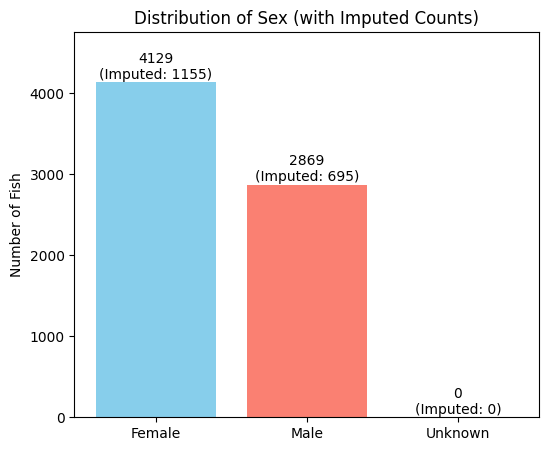

In [37]:
# Review Sex values after imputing

# Counts of each sex
sex_counts = fish['Sex'].value_counts()
sex_imputed_counts = fish[fish['Sex_imputed']].groupby('Sex').size()

plt.figure(figsize=(6,5))
bars = plt.bar(sex_counts.index, sex_counts.values, color=['skyblue', 'salmon'])

# Increase y-limit to make room for labels
plt.ylim(0, sex_counts.values.max() * 1.15)  # 15% extra space on top

# Add text labels
for bar, sex in zip(bars, sex_counts.index):
    count = sex_counts[sex]
    imputed = sex_imputed_counts.get(sex, 0)
    plt.text(bar.get_x() + bar.get_width()/2, count + 5, f"{count}\n(Imputed: {imputed})",
             ha='center', va='bottom')

plt.ylabel("Number of Fish")
plt.title("Distribution of Sex (with Imputed Counts)")
plt.show()

In [38]:
# See unique values of Sex field along with their % of total
#
display(fish['Sex'].value_counts(normalize=True) * 100) # show %
display(fish['Sex'].value_counts()) #show counts


Sex
Female     59.002572
Male       40.997428
Unknown     0.000000
Name: proportion, dtype: float64

Sex
Female     4129
Male       2869
Unknown       0
Name: count, dtype: int64

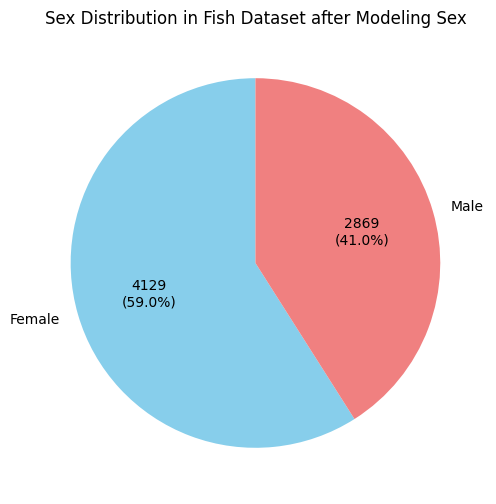

In [39]:
# Show Sex post modeling in a visual

# Get counts and remove zero entries
sex_counts = fish['Sex'].value_counts()
sex_counts = sex_counts[sex_counts > 0]

# Custom function to show both count and percentage
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct*total/100.0))
        return f"{count}\n({pct:.1f}%)"
    return my_autopct

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    sex_counts, 
    labels=sex_counts.index, 
    autopct=make_autopct(sex_counts), 
    startangle=90, 
    colors=['skyblue', 'lightcoral']
)
plt.title('Sex Distribution in Fish Dataset after Modeling Sex')
plt.show()

In [40]:
# Check for duplicates
#
#   - Result -> No new duplicates, continue with the 6 that are already there
#               These 6 “duplicates” are not data entry errors, they’re a side effect of the modeling/imputation
#               They are still real observations
#               They only look duplicated because of prediction

duplicate_rows_data = fish[fish.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)
fish[fish.duplicated()]

number of duplicate rows:  (6, 13)


,WaterbodyName,WaterbodyType,LandUseRegion,CommonName,Sex,ForkLength,Weight,Maturity,Age,Hg,Waterbody_age_mean,Age_imputed,Sex_imputed
3148,Lake Newell,Lake,South Saskatchewan,Lake Whitefish,Female,478.0,1102.0,Unknown,9.11,0.146,7.510430,True,True
3997,Moose Lake,Lake,Lower Athabasca,Cisco,Female,478.0,780.0,Unknown,7.67,0.067,7.467908,True,False
4031,Moose Lake,Lake,Lower Athabasca,Northern Pike,Female,478.0,1160.0,Unknown,5.45,0.495,7.467908,True,False
4454,Pigeon Lake,Lake,North Saskatchewan,Lake Whitefish,Male,478.0,1900.0,Unknown,6.87,0.040,7.702390,True,False
6056,Twin Valley Reservoir,Reservoir,South Saskatchewan,Northern Pike,Male,478.0,1102.0,Unknown,5.13,0.431,4.991268,True,True
6569,Willow Creek,River,South Saskatchewan,Longnose Sucker,Female,478.0,1102.0,Unknown,9.29,0.072,5.522593,True,True


In [41]:
# Checking null values
print(fish.isnull().sum())

WaterbodyName         0
WaterbodyType         0
LandUseRegion         0
CommonName            0
Sex                   0
ForkLength            0
Weight                0
Maturity              0
Age                   0
Hg                    0
Waterbody_age_mean    0
Age_imputed           0
Sex_imputed           0
dtype: int64


In [42]:
fish.info()

<class 'pandas.DataFrame'>
Index: 6998 entries, 0 to 7003
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   WaterbodyName       6998 non-null   category
 1   WaterbodyType       6998 non-null   category
 2   LandUseRegion       6998 non-null   category
 3   CommonName          6998 non-null   category
 4   Sex                 6998 non-null   category
 5   ForkLength          6998 non-null   float64 
 6   Weight              6998 non-null   float64 
 7   Maturity            6998 non-null   category
 8   Age                 6998 non-null   float64 
 9   Hg                  6998 non-null   float64 
 10  Waterbody_age_mean  6998 non-null   category
 11  Age_imputed         6998 non-null   bool    
 12  Sex_imputed         6998 non-null   bool    
dtypes: bool(2), category(7), float64(4)
memory usage: 359.5 KB


In [43]:
fish.nunique()

WaterbodyName          144
WaterbodyType            5
LandUseRegion            8
CommonName              24
Sex                      2
ForkLength             765
Weight                2409
Maturity                 4
Age                   1136
Hg                    1098
Waterbody_age_mean     144
Age_imputed              2
Sex_imputed              2
dtype: int64

<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px; font-size: 30px">
<span style="color: #7FDBFF;">
  Section 4 - Feature Engineering
</span>
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen;">Sub-Section 7: - Groupings</span>
</div>

In [44]:
fish.head()

,WaterbodyName,WaterbodyType,LandUseRegion,CommonName,Sex,ForkLength,Weight,Maturity,Age,Hg,Waterbody_age_mean,Age_imputed,Sex_imputed
0,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,383.0,610.0,Mature,8.27,0.136,8.078281,True,False
1,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,370.0,647.0,Mature,9.00,0.104,8.078281,False,False
2,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Male,374.0,710.0,Mature,6.00,0.057,8.078281,False,False
3,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,355.0,591.0,Mature,6.34,0.082,8.078281,True,False
4,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,347.0,600.0,Mature,9.00,0.143,8.078281,False,False


In [45]:
# Lets see how many records we have per WaterbodyName
fish['WaterbodyName'].value_counts().reset_index()

,WaterbodyName,count
0,Willow Creek,459
1,Gull Lake,222
2,Pigeon Lake,205
3,Moose Lake,196
4,Twin Valley Reservoir,142
...,...,...
139,Hay River,4
140,Loon River,4
141,Chain Lakes (Lower Chain Lake),2
142,North Saskatchewan River (between Edmonton and...,2


<div style="border: 2px solid orange; padding: 10px; border-radius: 8px;">

Research - we have identified high mercury WaterbodyNames and LandUseRegions

</div>

In [46]:
# Through some research, we have identified high mercury WaterbodyNames and LandUseRegions

# High HG WaterbodyName
high_Hg_WaterbodyNames =['Crowsnest Lake','Lac la Nonne','Lac Ste. Anne','Pine Coulee Reservoir','Twin Valley Reservoir','Red Deer River (near Blindman River Mouth)']

# High HG LandUseRegions
high_Hg_LandUseRegions = ['South Saskatchewan', 'Lower Athabasca', 'North Saskatchewan']

In [47]:
# Lets see how many records we have from our known high mercury LandUseRegions

# Get counts
counts = fish['LandUseRegion'].value_counts()

# Filter high-Hg lakes
result = counts[counts.index.isin(high_Hg_LandUseRegions)].reset_index()

# Rename columns clearly
result.columns = ['LandUseRegion', 'Count']

# Add percentage of total
total = len(fish)
result['Pct_Total'] = result['Count'] / total * 100  # multiply by 100 for % format
result['Pct_Total'] = result['Pct_Total'].round(2)   # optional rounding

result

,LandUseRegion,Count,Pct_Total
0,South Saskatchewan,1895,27.08
1,Lower Athabasca,1499,21.42
2,North Saskatchewan,954,13.63


In [48]:
# Lets see how many records we have from our known high mercury WaterbodyNames

# Get counts
counts = fish['WaterbodyName'].value_counts()

# Filter high-Hg lakes
result = counts[counts.index.isin(high_Hg_WaterbodyNames)].reset_index()

# Rename columns clearly
result.columns = ['WaterbodyName', 'Count']

# Add percentage of total
total = len(fish)
result['Pct_Total'] = result['Count'] / total * 100  # multiply by 100 for % format
result['Pct_Total'] = result['Pct_Total'].round(2)   # optional rounding

result

,WaterbodyName,Count,Pct_Total
0,Twin Valley Reservoir,142,2.03
1,Pine Coulee Reservoir,136,1.94
2,Lac Ste. Anne,124,1.77
3,Crowsnest Lake,106,1.51
4,Lac la Nonne,101,1.44
5,Red Deer River (near Blindman River Mouth),22,0.31


In [49]:
# Lets make a copy of fish now before we do groupings
fish_preGrouping = fish.copy()

In [50]:
# Add columns, group by Waterbody Name, add counts and average Hg

lake_counts = fish['WaterbodyName'].value_counts() # count how many fish come from each Waterbody
lake_avg_hg = fish.groupby('WaterbodyName')['Hg'].mean() # calculate avg Hg for each Waterbody

# Group Waterbody's, if it's in high_Hg, keep it as is, otherwise if it has less than 10 rows put it in "Other" category, and if its neither, put it in Other_Lakes category
def group_lake(name):
    if name in high_Hg_WaterbodyNames:
        return name
    elif lake_counts[name] < 10:
        return 'Other'
    else:
        return 'Other_Lakes'

fish['Waterbody_grouped'] = fish['WaterbodyName'].apply(group_lake)
fish['Lake_Count'] = fish['WaterbodyName'].map(lake_counts)
fish['Lake_Hg_Avg'] = fish['WaterbodyName'].map(lake_avg_hg)

# View results BEFORE one-hot encoding
print(fish[['WaterbodyName', 'Waterbody_grouped', 'Lake_Count', 'Lake_Hg_Avg']].head(10))

# One-hot encode grouped lakes
fish = pd.get_dummies(fish, columns=['Waterbody_grouped'], drop_first=True)




       WaterbodyName Waterbody_grouped  Lake_Count Lake_Hg_Avg
0  40 Mile Reservoir       Other_Lakes          64    0.550234
1  40 Mile Reservoir       Other_Lakes          64    0.550234
2  40 Mile Reservoir       Other_Lakes          64    0.550234
3  40 Mile Reservoir       Other_Lakes          64    0.550234
4  40 Mile Reservoir       Other_Lakes          64    0.550234
5  40 Mile Reservoir       Other_Lakes          64    0.550234
6  40 Mile Reservoir       Other_Lakes          64    0.550234
7  40 Mile Reservoir       Other_Lakes          64    0.550234
8  40 Mile Reservoir       Other_Lakes          64    0.550234
9  40 Mile Reservoir       Other_Lakes          64    0.550234


In [51]:
fish.head()

,WaterbodyName,WaterbodyType,LandUseRegion,CommonName,Sex,ForkLength,Weight,Maturity,Age,Hg,...,Sex_imputed,Lake_Count,Lake_Hg_Avg,Waterbody_grouped_Lac Ste. Anne,Waterbody_grouped_Lac la Nonne,Waterbody_grouped_Other,Waterbody_grouped_Other_Lakes,Waterbody_grouped_Pine Coulee Reservoir,Waterbody_grouped_Red Deer River (near Blindman River Mouth),Waterbody_grouped_Twin Valley Reservoir
0,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,383.0,610.0,Mature,8.27,0.136,...,False,64,0.550234,False,False,False,True,False,False,False
1,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,370.0,647.0,Mature,9.00,0.104,...,False,64,0.550234,False,False,False,True,False,False,False
2,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Male,374.0,710.0,Mature,6.00,0.057,...,False,64,0.550234,False,False,False,True,False,False,False
3,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,355.0,591.0,Mature,6.34,0.082,...,False,64,0.550234,False,False,False,True,False,False,False
4,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,347.0,600.0,Mature,9.00,0.143,...,False,64,0.550234,False,False,False,True,False,False,False


In [52]:
fish.info()

<class 'pandas.DataFrame'>
Index: 6998 entries, 0 to 7003
Data columns (total 22 columns):
 #   Column                                                        Non-Null Count  Dtype   
---  ------                                                        --------------  -----   
 0   WaterbodyName                                                 6998 non-null   category
 1   WaterbodyType                                                 6998 non-null   category
 2   LandUseRegion                                                 6998 non-null   category
 3   CommonName                                                    6998 non-null   category
 4   Sex                                                           6998 non-null   category
 5   ForkLength                                                    6998 non-null   float64 
 6   Weight                                                        6998 non-null   float64 
 7   Maturity                                                      6998 non-null 

In [53]:
# Convert Waterbody_age_mean and Lake_Hg_Avg to numeric, coerce any non-numeric values to NaN (just in case)
fish['Waterbody_age_mean'] = pd.to_numeric(fish['Waterbody_age_mean'], errors='coerce')
fish['Lake_Hg_Avg'] = pd.to_numeric(fish['Lake_Hg_Avg'], errors='coerce')

In [54]:
# See a sampling of the unique fields
fish.apply(pd.unique)

WaterbodyName                                                   ['40 Mile Reservoir', 'Amisk Lake', 'Angling L...
WaterbodyType                                                   ['Reservoir', 'Lake', 'River', 'Canal', 'Storm...
LandUseRegion                                                   ['South Saskatchewan', 'Upper Athabasca', 'Low...
CommonName                                                      ['Lake Whitefish', 'Northern Pike', 'Walleye',...
Sex                                                             ['Female', 'Male']
Categories (3, str): ['Fema...
ForkLength                                                      [383.0, 370.0, 374.0, 355.0, 347.0, 354.0, 348...
Weight                                                          [610.0, 647.0, 710.0, 591.0, 600.0, 558.0, 621...
Maturity                                                        ['Mature', 'Immature', 'Unknown', 'Triploid']
...
Age                                                             [8.27, 9.0, 6.0, 6.34, 4

In [55]:
# Save the clean file
fish.to_pickle('fish_clean.pkl')

<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px; font-size: 30px">
<span style="color: #7FDBFF;">
  Section 5 - Examine the Clean Data
</span>
</div>

<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px;">
<span style="color: lightgreen;">Sub-Section 8: - Examine the Clean Data Visually </span>
</div>




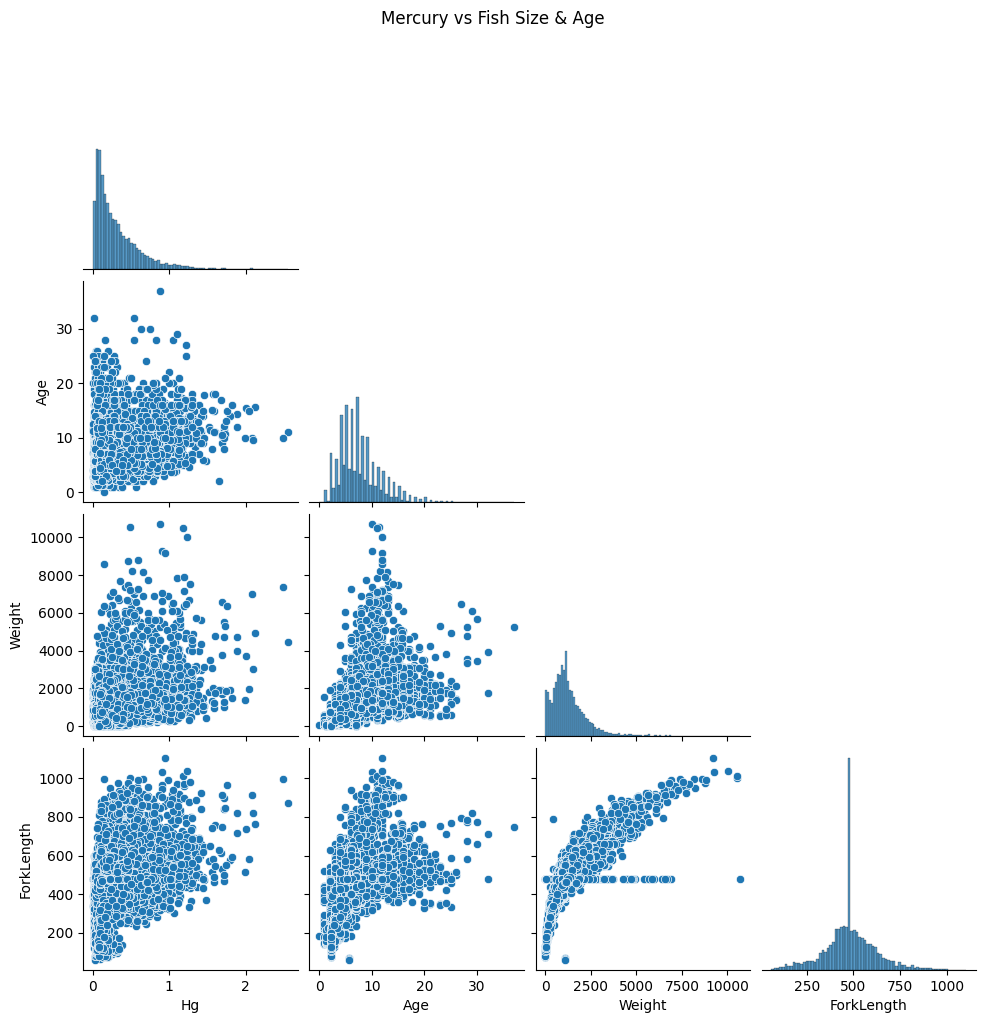

In [56]:
# Does Mercury increase with Age / Size of fish
# Plot Mercury vs Fish Size and Age

sns.pairplot(
    fish[['Hg', 'Age', 'Weight', 'ForkLength']],
    corner=True
)

plt.suptitle("Mercury vs Fish Size & Age", y=1.02)
plt.show()



<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 26px; text-decoration: underline;">
Mercury vs Fish Size & Age - Plot Analysis
</span>

<br><br>

<span style="color: #a9f0b3; font-size: 18px; text-decoration: underline;">
Histogram Observances
</span>
<br><br>

<span style="color: #e7eff0; font-size: 16px;">

Hg (top-left histogram)
- Highly right-skewed
- Most fish have low mercury
- A few have very high Hg (outliers)
Interpretation: - > Mercury contamination is not evenly distributed — a small number of fish drive the high values

Age (2nd from top)
- Slight right skew
- Most fish are young (under ~15 years)

Weight (3rd from top)
- Strong right skew
- Many small fish, few very large ones

ForkLength (bottom)
- More normally distributed
- Cleaner than weight (less extreme skew)
- This is why length often behaves better in models than weight
</span>
<br><br>

<span style="color: #a9f0b3; font-size: 18px; text-decoration: underline;">
Scatter Observances
</span>
<br><br>

<span style="color: #e7eff0; font-size: 16px;">

Hg vs Age (left column, 2nd row)
- Slight upward trend
- But very noisy
- Older fish tend to have more mercury, but age alone isn’t a strong predictor

Hg vs Weight (left column, 3rd row)
- Weak/moderate positive trend
- Huge spread
- Bigger fish → more Hg (on average), but not reliable alone

Hg vs ForkLength (bottom-left)
- Similar to weight
- Slightly cleaner pattern
- Length is a better size proxy than weight

Weight vs ForkLength (bottom-right area)
- VERY strong, curved relationship
- These are highly correlated (multicollinearity)
- Linear regression → may struggle if using both

</span>
</div>

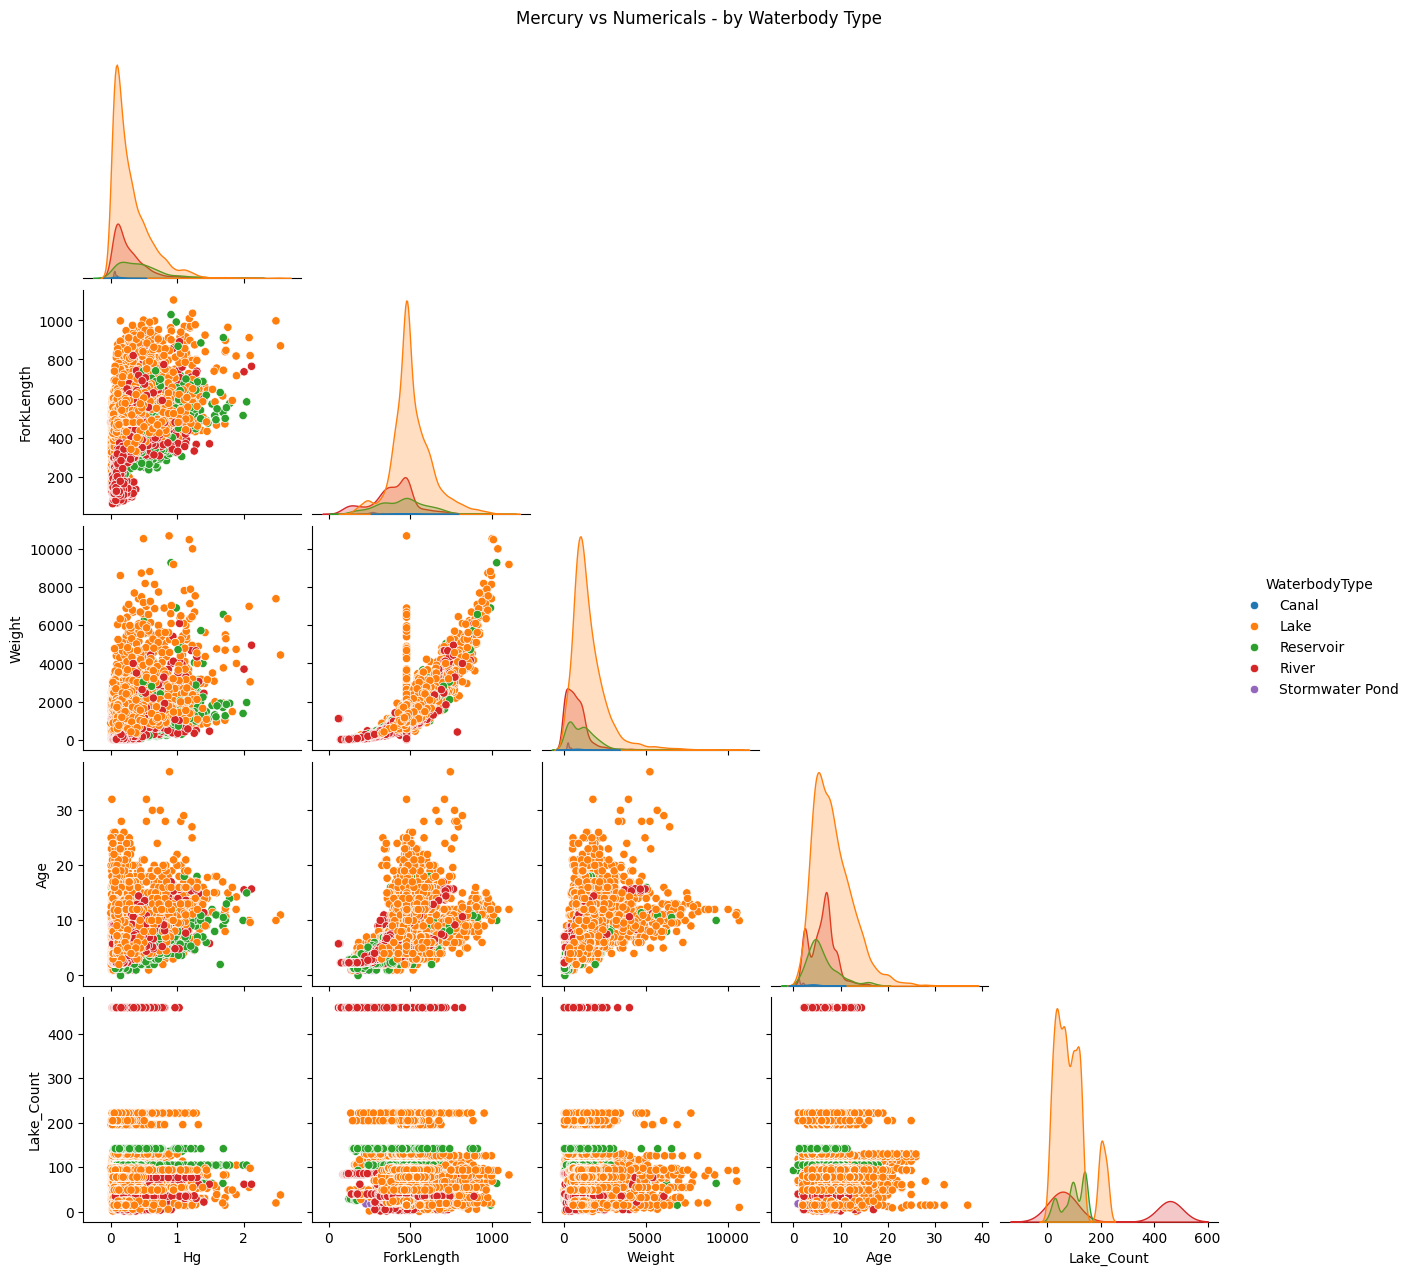

In [57]:
# Lets View pairplot of the numerical data (add WaterbodyType for contrast)

sns.pairplot(
    fish[['Hg', 'ForkLength', 'Weight', 'Age', 'Lake_Count', 'WaterbodyType']],
    hue='WaterbodyType',
    corner=True
)

plt.suptitle("Mercury vs Numericals - by Waterbody Type", y=1.02)
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 26px; text-decoration: underline;">
Mercury vs Numericals - by Waterbody Type - Plot Analysis
</span>

<br><br>

<span style="color: #e7eff0; font-size: 14px;">


WaterbodyType matters
---------------------

- 🟠 Lakes dominate the dataset  --> span the entire Hg range
- 🔴 Rivers tend to cluster differently  --> smaller fish, generally lower Hg
- 🟢 Reservoirs sit in between
- 🔵/🟣 (Canal / Stormwater) are sparse
- Mercury distribution is not uniform across environments


Weight vs ForkLength (middle)
-----------------------------
- Size relationships differ by environment
- Lakes -> wider spread (bigger fish)
- Rivers -> more constrained (smaller fish)
- Fish growth conditions differ by waterbody type


Age vs Weight / Length
----------------------
- Lakes -->  older + bigger fish
- Rivers --> generally younger/smaller


Lake_Count vs everything
------------------------
- Lakes (orange) → wide range of counts
- Rivers (red) → some very high counts
- Some locations are heavily sampled --> potential bias


Age vs Hg
---------
- Lakes --> higher Hg variability at all ages
- Rivers --> tighter, generally lower Hg
- In the previous plot above, there was no clear relationship
- In this plot we see multiple relationships that depend on Waterbody Type



Conclusion
----------
- Environment is a mjor driver
- WaterbodyType changes:
   - fish size
   - fish age
   - mercury levels
Summary --> “Mercury levels are influenced not just by fish size and age, but strongly by the type of waterbody, with lakes showing higher variability and higher contamination levels.”

</span>
</div>

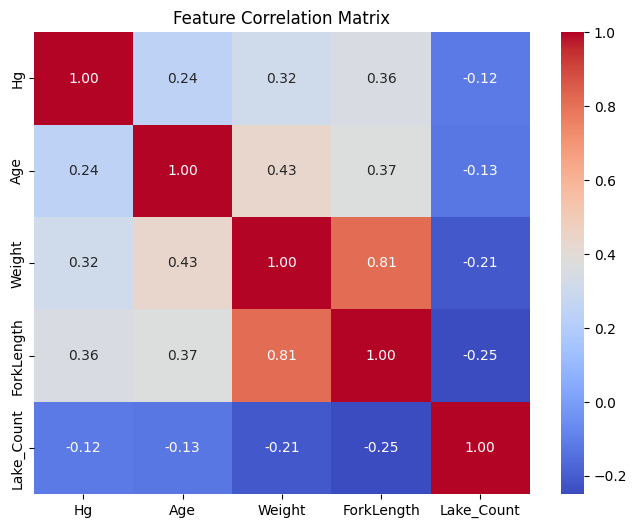

In [58]:
# Correlation Heatmap

corr = fish[['Hg', 'Age', 'Weight', 'ForkLength', 'Lake_Count']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Feature Correlation Matrix")
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 26px; text-decoration: underline;">
Correlation Matrix - Plot Analysis
</span>

<br><br>

The heatmap shows how our variables relate to each other using correlation coefficients (from -1 to +1).<br><br>

🔴 Strong Relationships <br>
        - Weight ↔ ForkLength (0.81)<br>
        - This is a very strong positive correlation. As fish length increases, weight increases significantly — which is expected biologically. <br><br>

🟠 Moderate Relationships<br>
        - Age ↔ Weight (0.43)<br>
        - Age ↔ ForkLength (0.37)<br>
        - Hg ↔ ForkLength (0.36)<br>
        - Hg ↔ Weight (0.32)<br><br>

🟡 Weak Relationships<br>
        - Hg ↔ Age (0.24) <br>
        - Slight tendency for mercury to increase with age, but not very strong.<br><br>

🔵 Negative Relationships<br>
        - Lake_Count vs all others (-0.12 to -0.25)<br>
        - Weak negative correlations<br>
        - Fish from lakes with higher counts slightly tend to have lower Hg, size, and age — but these relationships are weak and may not be meaningful.<br><br>

🧠 Key Takeaways<br>
        - Fish size (length & weight) is the strongest predictor cluster.<br>
        - Mercury accumulation appears more linked to size than age. <br>
        - Lake_Count likely has minimal impact on these variables.<br><br>

These suggest:
Older fish tend to be larger (longer and heavier).
Mercury (Hg) levels tend to increase with fish size.

<span style="color: #e7eff0; font-size: 14px;">

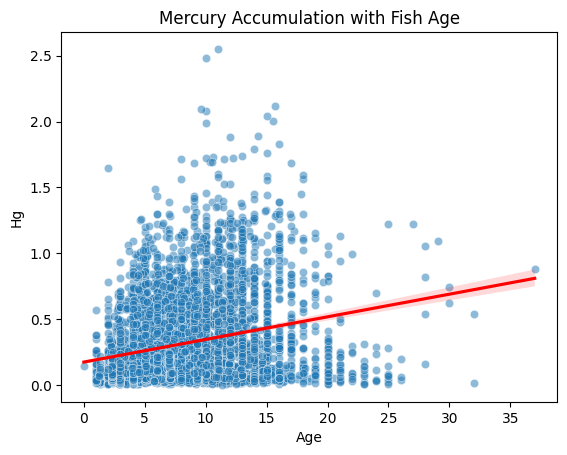

In [59]:
# Is Mercury accumulation related to Age (trend line suggests "Yes")

sns.scatterplot(
    data=fish,
    x='Age',
    y='Hg',
    alpha=0.5
)

sns.regplot(
    data=fish,
    x='Age',
    y='Hg',
    scatter=False,
    color='red'
)

plt.title("Mercury Accumulation with Fish Age")
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 26px; text-decoration: underline;">
Mercury Accumulation with Fish Age - Plot Analysis
</span>

<br><br>

This scatter plot shows how mercury (Hg) levels change with fish age.<br>

📈 Overall Trend<br>
The red regression line slopes upward → Hg tends to increase with age.<br>
However, the slope is fairly gentle, confirming what we saw in the correlation matrix (weak-to-moderate relationship).<br><br>

🔍 Variability (Key Insight) <br>
There’s huge spread in Hg values at most ages, especially between ~5–15 years.<br>
Fish of the same age can have very different mercury levels.<br>
This suggests age alone is not a strong predictor.<br>

🧠What Might Be Driving This?

Based on the earlier correlation matrix:

Size (Weight & ForkLength) likely plays a bigger role than age.
Older fish tend to be bigger, but not always → explains the scatter.

<span style="color: #e7eff0; font-size: 14px;">
</div>

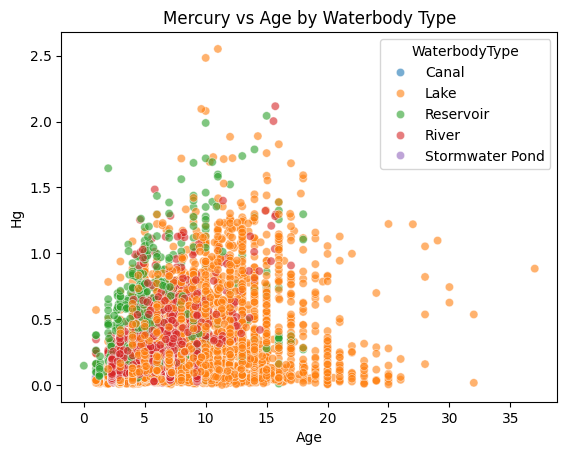

In [ ]:
# Do Waterbody types behave differently.

sns.scatterplot(
    data=fish,
    x='Age',
    y='Hg',
    hue='WaterbodyType',
    alpha=0.6
)

plt.title("Mercury vs Age by Waterbody Type")
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 26px; text-decoration: underline;">
Mercury vs Age by Waterbody Type - Plot Analysis
</span>

<br><br>

This plot adds an important layer: how mercury (Hg) vs. age varies by waterbody type. Here’s what stands out:

🟠 Lakes<br>
        - Widest spread in Hg values (from near 0 up to ~2.5+)<br>
        - Many of the highest mercury readings occur here<br>
        - Includes older fish (up to ~35+ years)<br>
        - Suggests lakes may have conditions that promote mercury accumulation (e.g., slower water turnover, sediment buildup).<br><br>

🟢 Reservoirs<br>
        - Moderate-to-high Hg levels, often clustered between 0.3–1.5<br>
        - Some high outliers (~2.0+), but less extreme than lakes<br>
        - Strong presence in mid-age fish (5–15 years)<br>
        - Likely similar to lakes but slightly less variable.<br><br>

🔴 Rivers<br>
        - More compressed Hg range, mostly below ~1.2<br>
        - Fewer extreme values<br>
        - Spread across ages but less dense at older ages<br>
        - Flowing water may reduce mercury buildup compared to lakes.<br><br>

🔵 Canals<br>
        - Generally lower Hg values, many near 0–0.5<br>
        - Less variation overall<br>
        - Possibly lower contamination or different ecological conditions.<br><br>

🟣 Stormwater Ponds<br>
        - Limited data, but mostly low Hg values<br>
        - Few points → hard to draw strong conclusions<br><br>

📈 Age Effect (Across All Types)<br>
        - Slight upward trend with age still exists<br>
        - BUT within each waterbody, variation is still high<br><br>

🧠 Big Takeaways<br>
        - Waterbody type matters a lot — sometimes more than age<br>
        - Lakes = highest risk for mercury accumulation<br>
        - Rivers & canals = generally lower Hg<br>
        - Age alone is not enough — environment plays a key role<br>

<span style="color: #e7eff0; font-size: 14px;">
</div>

<Figure size 640x480 with 0 Axes>

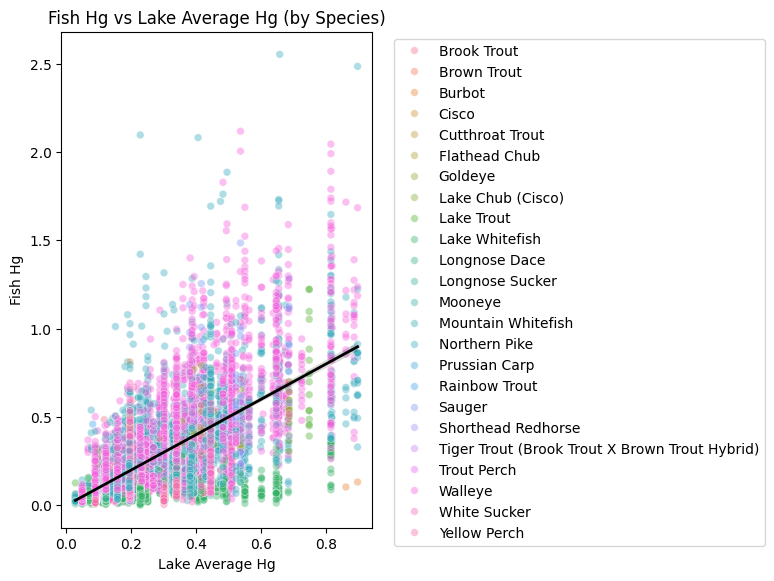

In [61]:
# Examine fish Hg vs Lake Hg
# As Lake Hg increases so does fish Hg
# Fish in high-mercury lakes tend to have high mercury themselves
# The environment (lake) is a dominant driver of mercury levels

plt.clf()
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=fish,
    x='Lake_Hg_Avg',
    y='Hg',
    hue='CommonName',
    alpha=0.4,
    s=30
)

sns.regplot(
    data=fish,
    x='Lake_Hg_Avg',
    y='Hg',
    scatter=False,
    color='black',
    line_kws={'linewidth':2}
)

plt.title("Fish Hg vs Lake Average Hg (by Species)")
plt.xlabel("Lake Average Hg")
plt.ylabel("Fish Hg")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 26px; text-decoration: underline;">
Fish Mercury vs Waterbody Mercury - Plot Analysis
</span>

<br><br>


There is a clear positive relationship between lake-level mercury and individual fish mercury, indicating that environmental exposure is a primary driver. <br>
However, substantial variability within lakes suggests that biological factors such as species and size also play a significant role in mercury accumulation.<br>

<br>
1 - Strong positive relationship (main story)<br>
        - The regression line clearly slopes upward<br>
        - Higher lake mercury --> higher fish mercury<br>
        - Environment is a major driver of fish mercury levels<br><br>

2 - Vertical bands = shared lake effect<br>
        - Those vertical “columns” of points = same Lake_Hg_Avg<br>
        - Many fish come from the same Waterbody <br>
        - Waterbody set the baseline mercury exposure <br><br>

3 - Huge spread within each lake (very important)<br>
        - At each vertical stripe: --> Fish Hg ranges a LOT (e.g., 0.2 → 1.2+)<br><br>


Takeaways:<br>
        - Waterbody is not the whole story<br>
        - Fish-specific factors matter a lot<br>
        - Likely drivers: Age, Size (ForkLength / Weight), Species

<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px; font-size: 30px">
<span style="color: #7FDBFF;">
  Section 6 - Simple Linear Regression Model (Base)
</span>
</div>


<div style="border: 2px solid yellow; padding: 10px; border-radius: 8px;">
<span style="color: yellow;">Base Model - Linear Regression </span>


Model Characteristics
- Simple Linear Regression
- Perform LInear regression of Hg vs each of the numerical features


In [62]:
fish.head()

,WaterbodyName,WaterbodyType,LandUseRegion,CommonName,Sex,ForkLength,Weight,Maturity,Age,Hg,...,Sex_imputed,Lake_Count,Lake_Hg_Avg,Waterbody_grouped_Lac Ste. Anne,Waterbody_grouped_Lac la Nonne,Waterbody_grouped_Other,Waterbody_grouped_Other_Lakes,Waterbody_grouped_Pine Coulee Reservoir,Waterbody_grouped_Red Deer River (near Blindman River Mouth),Waterbody_grouped_Twin Valley Reservoir
0,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,383.0,610.0,Mature,8.27,0.136,...,False,64,0.550234,False,False,False,True,False,False,False
1,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,370.0,647.0,Mature,9.00,0.104,...,False,64,0.550234,False,False,False,True,False,False,False
2,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Male,374.0,710.0,Mature,6.00,0.057,...,False,64,0.550234,False,False,False,True,False,False,False
3,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,355.0,591.0,Mature,6.34,0.082,...,False,64,0.550234,False,False,False,True,False,False,False
4,40 Mile Reservoir,Reservoir,South Saskatchewan,Lake Whitefish,Female,347.0,600.0,Mature,9.00,0.143,...,False,64,0.550234,False,False,False,True,False,False,False


In [63]:
# Lets look at the mean and std deviation of the Hg before any modeling

print('Hg mean: ', fish['Hg'].mean())
print('Hg std: ', fish['Hg'].std())

Hg mean:  0.30663060874535575
Hg std:  0.28893617349083006


One-variable linear regression results (sorted by R²):

Lake_Hg_Avg  → R² = 0.412, RMSE = 0.221
ForkLength   → R² = 0.126, RMSE = 0.270
Weight       → R² = 0.100, RMSE = 0.274
Age          → R² = 0.058, RMSE = 0.280
Lake_Count   → R² = 0.014, RMSE = 0.287


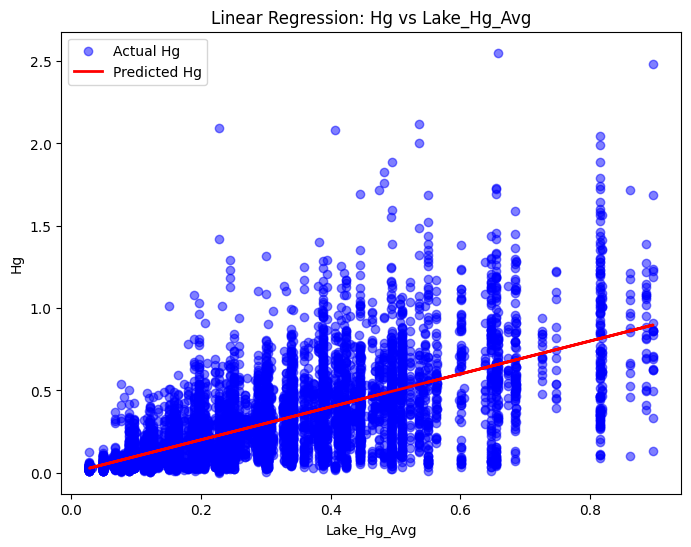

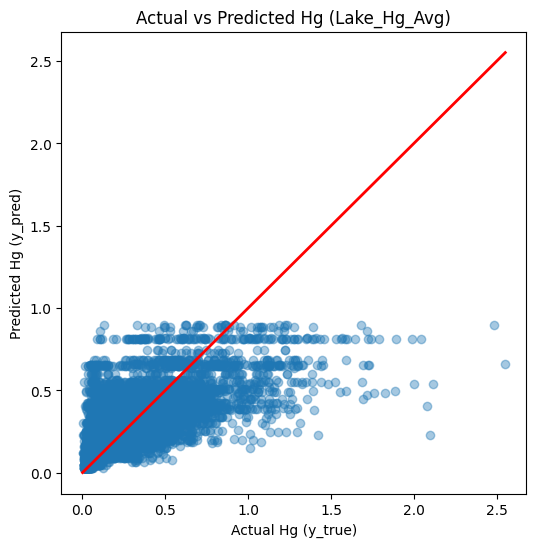

In [64]:
# Base Model --> Simple linear regression using one numerical variable

numeric_features = [
    'ForkLength',
    'Weight',
    'Age',
    'Lake_Count',
    'Lake_Hg_Avg'
]

results = []

# -------------------------
# 1. Loop through features
# -------------------------
for feature in numeric_features:
    X = fish[[feature]]
    y = fish['Hg']

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    results.append((feature, r2, rmse))

# -------------------------
# 2. Sort + print results
# -------------------------
results.sort(key=lambda x: x[1], reverse=True)

print("One-variable linear regression results (sorted by R²):\n")
for feature, r2, rmse in results:
    print(f"{feature:12s} → R² = {r2:.3f}, RMSE = {rmse:.3f}")

# -------------------------
# 3. top model
# -------------------------
def build_top_model(fish, results):
    top_feature = results[0][0]
    X = fish[[top_feature]]
    y = fish['Hg']
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_pred = model.predict(X)
    
    return X, y, y_pred, top_feature

# -------------------------
# 4. Call function
# -------------------------
X_top, y_top, y_pred_top, top_feature = build_top_model(fish, results)

# -------------------------
# 5. Regression plot
# -------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_top, y_top, color='blue', alpha=0.5, label='Actual Hg')
plt.plot(X_top, y_pred_top, color='red', linewidth=2, label='Predicted Hg')

plt.xlabel(top_feature)
plt.ylabel('Hg')
plt.title(f'Linear Regression: Hg vs {top_feature}')
plt.legend()
plt.show()

# -------------------------
# 6. Actual vs Predicted plot
# -------------------------
plt.figure(figsize=(6,6))

plt.scatter(y_top, y_pred_top, alpha=0.4)

# perfect prediction line
plt.plot(
    [y_top.min(), y_top.max()],
    [y_top.min(), y_top.max()],
    color='red', linewidth=2
)

plt.xlabel("Actual Hg (y_true)")
plt.ylabel("Predicted Hg (y_pred)")
plt.title(f"Actual vs Predicted Hg ({top_feature})")

plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 26px; text-decoration: underline;">
Base Model - Simple Linear Regression - Plot Analysis
</span>

<br><br>

Linear Regression Plot

While linear regression captures the overall positive relationship between lake-level and fish mercury, it systematically underestimates high mercury values and fails to account for substantial within-lake variability, <br>
indicating that additional biological and environmental features are needed for accurate prediction.

Best single variable for predicting Hg is Lake_Hg_Avg with an R² = 0.412 and RMSE = 0.221

1. Model captures the main trend<br>
        - The red line has a clear positive slope<br>
        - Model correctly learned that Higher lake Hg → higher fish Hg<br>
        - So at a high level: ✔ direction is right<br><br>

2. Systematic Underfitting<br>
        - Look at higher values (right side)<br>
        - Many actual points are well above the red line<br>
        - Model underpredicts high Hg fish<br>
        - At low values some points slightly above line → mild underprediction there too<br>
        - The linear model is too simple to capture extremes<br><br>

3. Huge vertical spread (missed variance)<br>
        - At each x-value the Actual Hg ranges widely<br>
        - Prediction is just one value (the line)<br>
        - Linear regression assumes constant variance (which is violated)<br><br>


Actual vs Predicted Plot<br>

1. Strong underprediction at high values (biggest issue)<br>
        - Look at the right side: Actual Hg goes up to ~2.5 while Predicted Hg caps around ~0.9<br>
        - Model cannot predict high mercury values at all<br><br>

2. Predictions are “compressed”<br>
        - The predictions live in a narrow band: ~0.1 to ~0.9 while actual values are ~0 to ~2.5<br>
        - Linear regression is averaging things too much<br><br>

3. Systematic bias (not random error)
        - Low Hg → slightly overpredicted
        - High Hg → heavily underpredicted
        - This is NOT random noise, It’s a model limitation

4. Non-linear relationship


In [65]:
fish.info()

<class 'pandas.DataFrame'>
Index: 6998 entries, 0 to 7003
Data columns (total 22 columns):
 #   Column                                                        Non-Null Count  Dtype   
---  ------                                                        --------------  -----   
 0   WaterbodyName                                                 6998 non-null   category
 1   WaterbodyType                                                 6998 non-null   category
 2   LandUseRegion                                                 6998 non-null   category
 3   CommonName                                                    6998 non-null   category
 4   Sex                                                           6998 non-null   category
 5   ForkLength                                                    6998 non-null   float64 
 6   Weight                                                        6998 non-null   float64 
 7   Maturity                                                      6998 non-null 

In [66]:
fish.head().T

,0,1,2,3,4
WaterbodyName,40 Mile Reservoir,40 Mile Reservoir,40 Mile Reservoir,40 Mile Reservoir,40 Mile Reservoir
WaterbodyType,Reservoir,Reservoir,Reservoir,Reservoir,Reservoir
LandUseRegion,South Saskatchewan,South Saskatchewan,South Saskatchewan,South Saskatchewan,South Saskatchewan
CommonName,Lake Whitefish,Lake Whitefish,Lake Whitefish,Lake Whitefish,Lake Whitefish
Sex,Female,Female,Male,Female,Female
ForkLength,383.0,370.0,374.0,355.0,347.0
Weight,610.0,647.0,710.0,591.0,600.0
Maturity,Mature,Mature,Mature,Mature,Mature
Age,8.27,9.0,6.0,6.34,9.0
Hg,0.136,0.104,0.057,0.082,0.143


<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px; font-size: 30px">
<span style="color: #7FDBFF;">
  Section 7 - Explore Other Models
</span>
</div>


<div style="border: 2px solid yellow; padding: 10px; border-radius: 8px;">
<span style="color: yellow;">Model A - Linear Regression (All features and CV) </span>


Model Characteristics
- Linear Regression inside a Pipeline
- Linear Regression with one-hot encoding and 5-fold cross-validation
- Uses all features with preprocessing (scaling + encoding)
- Evaluated using 5-fold cross-validation
- Boolean dummy variables are treated as numeric features 
- Applies one-hot encoding to categorical (non-dummy) columns, and standardizes numeric features
- Produces out-of-sample predictions (y_pred_cv_a)
- RMSE is a cross-validated estimate (unbiased)


Model A - Linear Regression (All Features, Proper CV)
---------------------------------------------------
Categorical features: ['WaterbodyName', 'WaterbodyType', 'LandUseRegion', 'CommonName', 'Sex', 'Maturity']
Numerical features: ['ForkLength', 'Weight', 'Age', 'Waterbody_age_mean', 'Lake_Count', 'Lake_Hg_Avg']
Cross-Validated RMSE: 0.1673
Cross-Validated R²: 0.6647


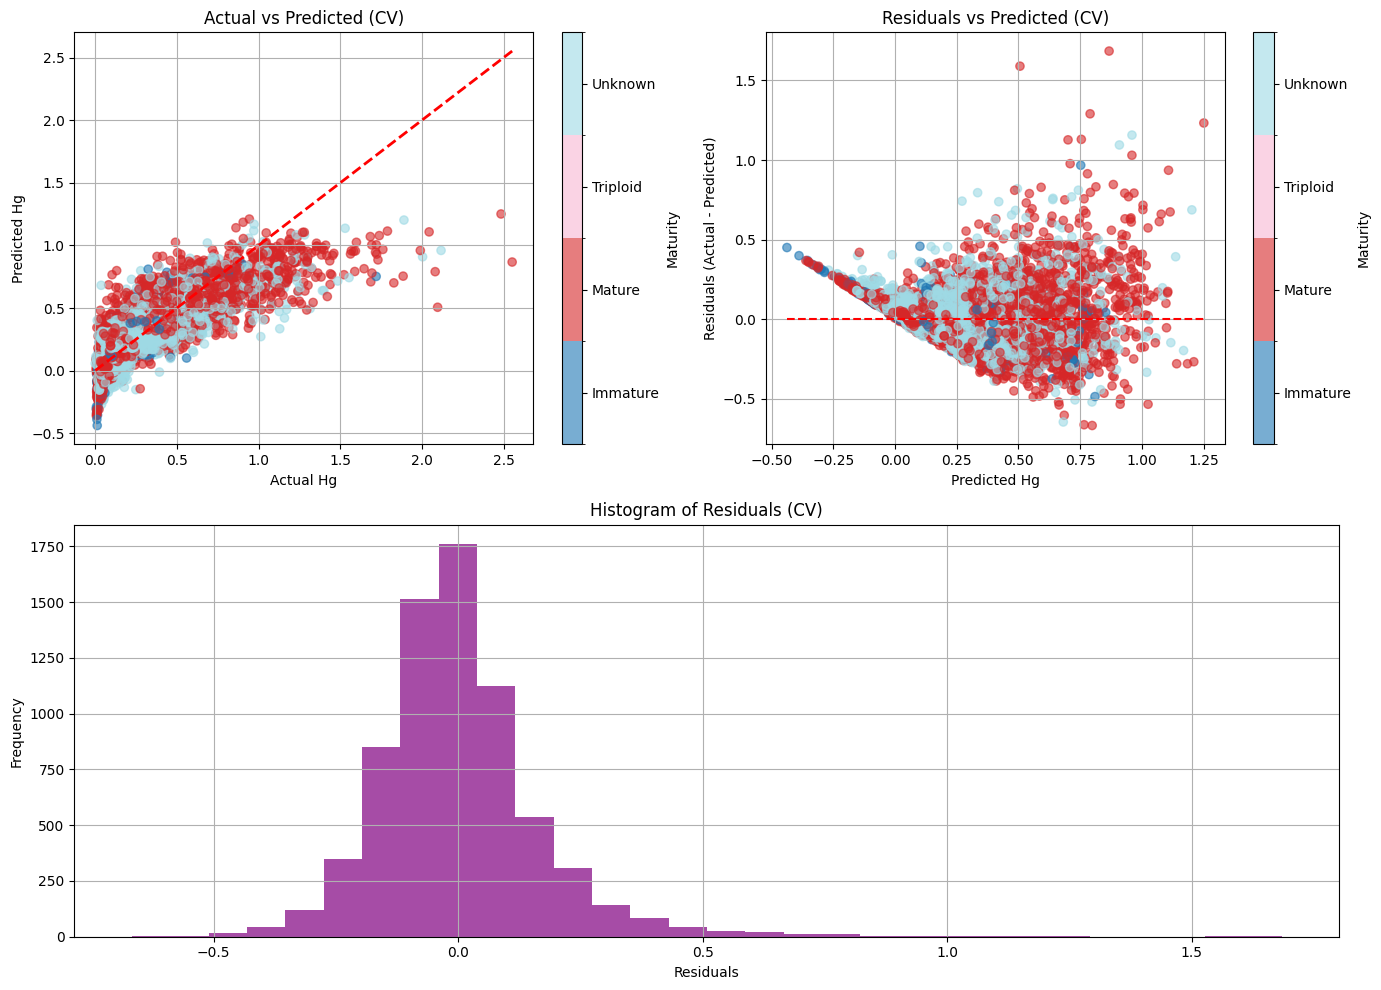

In [68]:

# Model A – Linear Regression with one-hot encoding and 5-fold cross-validation
# Uses all columns. Boolean dummy variables are treated as numeric features. Applies one-hot encoding to categorical (non-dummy) columns, and standardizes numeric features.


print("Model A - Linear Regression (All Features, Proper CV)")
print("---------------------------------------------------")

# 1. Define X and y
y = fish['Hg']
X = fish.drop('Hg', axis=1)


# 2. Identify column types
categorical_features = X.select_dtypes(include='category').columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()


print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)


# 3. Preprocessing (NO leakage)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)


# 4. Full Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 5. Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)


# 6. Cross-validated predictions
y_pred_cv_a = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)


# 7. Evaluation
rmse = np.sqrt(mean_squared_error(y, y_pred_cv_a))
r2 = r2_score(y, y_pred_cv_a)

print(f"Cross-Validated RMSE: {rmse:.4f}")
print(f"Cross-Validated R²: {r2:.4f}")

# Add scores
rmse_scores_a = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

rmse_mean_lra = -rmse_scores_a.mean()
rmse_std_lra = rmse_scores_a.std()


# 8. Residuals
residuals = y - y_pred_cv_a


# 9. Coloring (Maturity)
color_by = fish['Maturity'].fillna("Unknown").astype('category')

cat_labels = color_by.cat.categories
color_codes = color_by.cat.codes

cmap = plt.get_cmap('tab20', len(cat_labels))
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(len(cat_labels) + 1) - 0.5,
    ncolors=len(cat_labels)
)


# 10. Plot diagnostics
fig = plt.figure(figsize=(14, 10))

# --- Actual vs Predicted ---
ax1 = plt.subplot2grid((2, 2), (0, 0))
sc1 = ax1.scatter(y, y_pred_cv_a, c=color_codes, cmap=cmap, norm=norm, alpha=0.6)

ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
ax1.set_xlabel("Actual Hg")
ax1.set_ylabel("Predicted Hg")
ax1.set_title("Actual vs Predicted (CV)")
ax1.grid(True)

cbar1 = plt.colorbar(sc1, ax=ax1, ticks=np.arange(len(cat_labels)))
cbar1.set_ticklabels(cat_labels)
cbar1.set_label("Maturity")

# --- Residuals vs Predicted ---
ax2 = plt.subplot2grid((2, 2), (0, 1))
sc2 = ax2.scatter(y_pred_cv_a, residuals, c=color_codes, cmap=cmap, norm=norm, alpha=0.6)

ax2.hlines(0, y_pred_cv_a.min(), y_pred_cv_a.max(), colors='red', linestyles='dashed')
ax2.set_xlabel("Predicted Hg")
ax2.set_ylabel("Residuals (Actual - Predicted)")
ax2.set_title("Residuals vs Predicted (CV)")
ax2.grid(True)

cbar2 = plt.colorbar(sc2, ax=ax2, ticks=np.arange(len(cat_labels)))
cbar2.set_ticklabels(cat_labels)
cbar2.set_label("Maturity")

# --- Histogram ---
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.hist(residuals, bins=30, color='purple', alpha=0.7)
ax3.set_xlabel("Residuals")
ax3.set_ylabel("Frequency")
ax3.set_title("Histogram of Residuals (CV)")
ax3.grid(True)

plt.tight_layout()
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Model A - Linear Regression (All Features, Proper CV) - Plot Analysis
</span>

<br><br>

RMSE: 0.1673<br>
R²: 0.6647

Cross-validated results confirm that the linear model struggles to capture the variability in fish mercury levels, particularly at higher concentrations, where errors increase substantially. <br>
This indicates that the relationship is not strictly linear and that additional features or more flexible models are required.<br>

We are now using  cross-validated predictions (CV)<br>

1. Actual vs Predicted (CV)<br>
    - Predictions are now out-of-sample (model trains on part of the data, and predicts on other data)<br>
    - Much more realistic performance<br>
    - Each prediction is made on data the model hasn’t seen<br>
    - Underprediction at high Hg<br>
    - Compression of predictions<br>
    - The model genuinely struggles, not just overfitting<br><br>

2. Residuals vs Predicted<br>
    - Checks model assumptions<br>
    - Shows error patterns<br>
    - Funnel shape<br>
    - Small spread at low values<br>
    - Large spread at high values<br>
    - This shows heteroskedasticity (the unequal, non-constant variance of errors (residuals)). <br>
    - Presence of heteroskedasticity in the model means that you cannot trust standard model diagnostics (e.g. F-test, R-squared)<br><br>







      


In [69]:
# This is an Ordinary Least Squares (OLS) summary

# Step 1 - Separate features and target
X = fish.drop('Hg', axis=1)
y = fish['Hg']

# Step 2 - Convert all categorical/object/bool columns to dummies
cat_cols = X.select_dtypes(['category', 'object', 'bool']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Step 3 - Force all columns to float64
X = X.astype('float64')

# Step 4 - Drop constant columns
X = X.loc[:, X.nunique() > 1]

# Step 5 - Drop rows with any NaNs
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask]
y = y.loc[mask]

# Step 6 - Add intercept
X = sm.add_constant(X)

# Step 7 - Check Shapes
print("X shape:", X.shape, "y shape:", y.shape)

# Step 8 - Fit OLS
model = sm.OLS(y, X).fit()
print(model.summary())

# Step 9 - Residual diagnostics
residuals = model.resid
fitted = model.fittedvalues

res_skew = residuals.skew()
res_kurt = residuals.kurtosis()
jb_stat, jb_p = jarque_bera(residuals)
omni_stat, omni_p = normaltest(residuals)

print(f"Residual skewness: {res_skew:.3f}")
print(f"Residual kurtosis (excess): {res_kurt:.3f}")
print(f"Jarque-Bera: {jb_stat:.2f}, p-value: {jb_p:.3f}")
print(f"Omnibus (D'Agostino-Pearson): {omni_stat:.2f}, p-value: {omni_p:.3f}")

X shape: (6998, 197) y shape: (6998,)
                            OLS Regression Results                            
Dep. Variable:                     Hg   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     84.88
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:01:27   Log-Likelihood:                 2790.1
No. Observations:                6998   AIC:                            -5230.
Df Residuals:                    6823   BIC:                            -4031.
Df Model:                         174                                         
Covariance Type:            nonrobust                                         
                                                                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 28px; text-decoration: underline;">
Model A - Ordinary Least Squares
</span>

<br><br>

The full linear regression model explains approximately 68% of the variability in fish mercury levels, with lake-level mercury, fish age, and size emerging as the most significant predictors.<br>
The inclusion of waterbody-specific indicators further improves performance, highlighting the importance of location.<br>
However, the large number of features and presence of many insignificant variables suggest potential overfitting and model complexity issues.<br><br>

<span style="color: #d2b075; font-size: 18px;text-decoration: underline">Observations:</span><br><br>

1. Overall model performance<br>
    - R² = 0.684<br>
    - The model explains about 68% of the variation in fish mercury levels<br>
    - Much better than the one-variable model<br>
    - Still not perfect → 32% unexplained<br><br>

2. We are using A LOT of features<br>
    - 197 features total (mostly from One-hot encoded WaterbodyName)<br>
    - 74 model variables<br>
    - This model is complex and heavily dependent on location<br><br>

3. Most important predictor<br>
    - Lake_Hg_Avg: coef = 0.6370, t = 25.4 (VERY strong)<br><br>

4. Many variables are NOT significant<br>
    - Many features have high p-values (eg Individual Waterbody names)<br>
    - These don’t add meaningful signal add just add noise<br>
    - This suggest that the model may be overparameterized<br><br>

5. Feature Summary<br>
    - Lake Hg is the dominant driver<br>
    - Fish biology matters (age, size)<br>
    - Location matters a lot<br>
    - Linear model improves with more features<br><br>

<span style="color: #d2b075; font-size: 18px;text-decoration: underline">Stats Summary:</span><br><br>


1. Residual skewness: 1.442<br>
    - Skewness measures asymmetry, 0 = perfectly symmetric (ideal)<br>
    - Model has: +1.44 = strongly right-skewed<br>
    - Model has many large positive errors (frequently underestimating Hg, especially for high values)<br><br>



2. Residual kurtosis (excess): 7.588<br>
    - Kurtosis measures tail heaviness<br>
    - When Values is 0 => normal distribution<br>
    - Our model is 7.6 => VERY heavy tails<br>
    - You have lots of extreme errors (outliers)<br>
    - The model occasionally makes very large mistakes<br><br>

3. Jarque-Bera test: p-value = 0.000<br>
4. Omnibus test: p-value = 0.000<br>
    - Both tests check: “Are residuals normally distributed?”<br>
    - Result: p = 0.000 → reject normality<br>
    - The residuals are NOT normally distributed<br><br>


<span style="color: #d2b075; font-size: 18px;text-decoration: underline">Model Conclusion:</span><br><br>

1. The model is biased<br>
    - Right skew → underpredicts high Hg<br>
    - Not symmetric → systematic error<br><br>

2. The model misses extremes<br>
    - High kurtosis → fails on outliers<br>
    - Can’t capture high mercury fish<br><br>

3. Linear model assumptions are violated<br>
    - Residuals arent normal<br>
    - Variance is not constant<br>
    - Relationship not linear<br>



<div style="border: 2px solid yellow; padding: 10px; border-radius: 8px;">
<span style="color: yellow;">Model B - Linear Regression (Feature Selection and CV) </span>


Model Characteristics
- Linear Regression inside a Pipeline
- Linear Regression with one-hot encoding and 5-fold cross-validation
- Randomly samples combinations of up to 5 features
- Fits a Linear Regression model for each combination
- Calculates RMSE and R² for each model
- Identifies the set of features that produces the lowest RMSE (best predictive performance)
- cross_val_predict → out-of-fold predictions (much more honest)


Model B - Linear Regression - Best Combo 5 features
---------------------------------------------------
Best features: ('ForkLength', 'Lake_Hg_Avg', 'Waterbody_grouped_Lac Ste. Anne', 'CommonName_Walleye')
Cross-Validated RMSE: 0.1962
Cross-Validated R²: 0.5388


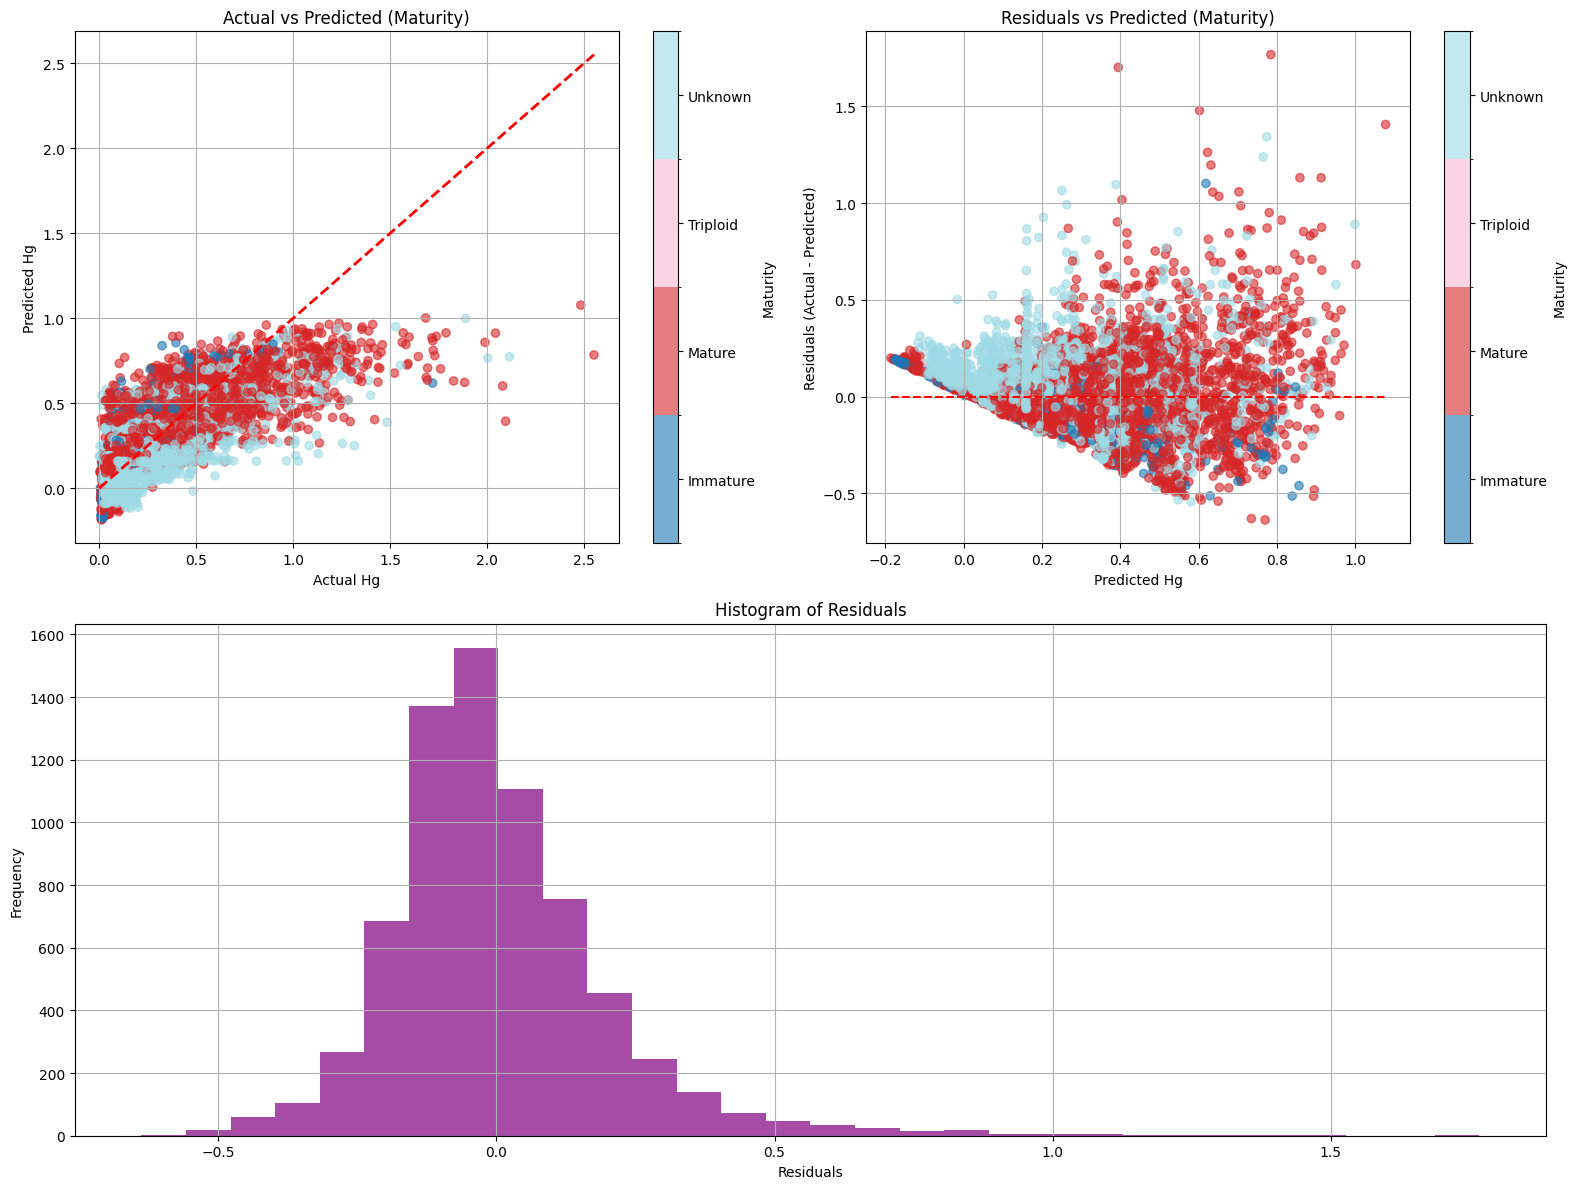

In [ ]:
# Model B - Linear regression with feature selection evaluated using 5-fold cross-validation.

# Step 0: One-hot encode categorical columns
cat_cols = ['CommonName', 'Sex', 'Maturity', 'WaterbodyType', 'LandUseRegion']
fish_encoded = pd.get_dummies(fish, columns=cat_cols, drop_first=True)


# Step 1: Define features
numeric_cols = [
    'ForkLength', 'Weight', 'Age', 'Lake_Count', 'Lake_Hg_Avg',
    'Age_imputed', 'Sex_imputed',
    'Waterbody_grouped_Lac Ste. Anne',
    'Waterbody_grouped_Lac la Nonne',
    'Waterbody_grouped_Other',
    'Waterbody_grouped_Other_Lakes',
    'Waterbody_grouped_Pine Coulee Reservoir',
    'Waterbody_grouped_Red Deer River (near Blindman River Mouth)',
    'Waterbody_grouped_Twin Valley Reservoir',
    'Waterbody_age_mean'
]

one_hot_cols = [c for c in fish_encoded.columns if any(cat in c for cat in cat_cols)]
all_features = numeric_cols + one_hot_cols


# Step 2: CV setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)


# Step 3: Random feature combinations
max_combo_size = 5
num_samples = 300
sampled_combos = []

for r in range(1, max_combo_size + 1):
    combos = list(itertools.combinations(all_features, r))
    if len(combos) == 0:
        continue
    n = min(num_samples, len(combos))
    sampled_combos += random.sample(combos, n)


# Step 4: Evaluate combinations
results = []

for selected in sampled_combos:
    X = fish_encoded[list(selected)]
    y = fish_encoded['Hg']

    model = LinearRegression()

    scores = cross_validate(
        model, X, y, cv=cv,
        scoring=['neg_root_mean_squared_error', 'r2'],
        n_jobs=-1
    )

    results.append({
        'features': selected,
        'rmse_mean': -scores['test_neg_root_mean_squared_error'].mean(),
        'rmse_std': scores['test_neg_root_mean_squared_error'].std(),
        'r2_mean': scores['test_r2'].mean(),
        'r2_std': scores['test_r2'].std()
    })


# Step 5: Best model
results_df = pd.DataFrame(results)
results_df.sort_values('rmse_mean', inplace=True)

print("Model B - Linear Regression - Best Combo 5 features")
print("---------------------------------------------------")
best_features = results_df.iloc[0]['features']
print("Best features:", best_features)


# Step 6: Cross-validated predictions
X_best = fish_encoded[list(best_features)]
y = fish_encoded['Hg']

model = LinearRegression()

y_pred_lr = cross_val_predict(model, X_best, y, cv=cv, n_jobs=-1)
residuals = y - y_pred_lr

rmse_lrf = np.sqrt(mean_squared_error(y, y_pred_lr))
r2_lrf = r2_score(y, y_pred_lr)

rmse_mean_lrf = results_df.iloc[0]['rmse_mean']
rmse_std_lrf = results_df.iloc[0]['rmse_std']
r2_mean_lrf = results_df.iloc[0]['r2_mean']
r2_std_lrf = results_df.iloc[0]['r2_std']

print(f"Cross-Validated RMSE: {rmse_lrf:.4f}")
print(f"Cross-Validated R²: {r2_lrf:.4f}")


# Step 7: Proper categorical coloring (Maturity)
color_var = fish['Maturity'].fillna("Unknown")
categories = color_var.astype('category')
cat_labels = categories.cat.categories
colors = categories.cat.codes

# Proper discrete colormap
cmap = plt.get_cmap('tab20', len(cat_labels))
norm = mcolors.BoundaryNorm(
    boundaries=np.arange(len(cat_labels) + 1) - 0.5,
    ncolors=len(cat_labels)
)


# Step 8: Plot diagnostics
fig = plt.figure(figsize=(16, 12))

# --- Actual vs Predicted ---
ax1 = plt.subplot2grid((2, 2), (0, 0))
sc1 = ax1.scatter(y, y_pred_lr, c=colors, cmap=cmap, norm=norm, alpha=0.6)

ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
ax1.set_xlabel("Actual Hg")
ax1.set_ylabel("Predicted Hg")
ax1.set_title("Actual vs Predicted (Maturity)")
ax1.grid(True)

cbar1 = plt.colorbar(sc1, ax=ax1, ticks=np.arange(len(cat_labels)))
cbar1.set_ticklabels(cat_labels)
cbar1.set_label("Maturity")

# --- Residuals vs Predicted ---
ax2 = plt.subplot2grid((2, 2), (0, 1))
sc2 = ax2.scatter(y_pred_lr, residuals, c=colors, cmap=cmap, norm=norm, alpha=0.6)

ax2.hlines(0, y_pred_lr.min(), y_pred_lr.max(), colors='red', linestyles='dashed')
ax2.set_xlabel("Predicted Hg")
ax2.set_ylabel("Residuals (Actual - Predicted)")
ax2.set_title("Residuals vs Predicted (Maturity)")
ax2.grid(True)

cbar2 = plt.colorbar(sc2, ax=ax2, ticks=np.arange(len(cat_labels)))
cbar2.set_ticklabels(cat_labels)
cbar2.set_label("Maturity")

# --- Histogram of Residuals ---
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.hist(residuals, bins=30, color='purple', alpha=0.7)
ax3.set_xlabel("Residuals")
ax3.set_ylabel("Frequency")
ax3.set_title("Histogram of Residuals")
ax3.grid(True)

plt.tight_layout()
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Model B - Linear Regression & Comparison to Model A
</span>

<br>

RMSE: 0.2066<br>
R²: 0.4888

The cross-validated diagnostics of Model B reveal systematic underprediction at higher mercury levels, increasing error variance, and non-normal residuals, indicating that the linear model is <br>
unable to capture the true complexity of the relationship (similar to Model A).

The earlier model (Model A) appeared to perform well because it was evaluated on the same data it was trained on, whereas the cross-validated model reveals greater error, clear bias, and structural issues, providing a more realistic assessment of performance.

While Model A uses all available features and achieves slightly better performance, Model B achieves comparable results with far fewer variables. Both models exhibit similar patterns of bias and heteroskedasticity, indicating that the primary limitation lies in the linear model structure rather than feature selection.


<span style="color: #d2b075; font-size: 18px;text-decoration: underline">Model A & B - Conclusions:</span><br><br>

- Two linear regression models were evaluated using cross-validation to predict fish mercury (Hg) levels.

- Model A incorporated all available features, including fully one-hot encoded categorical variables, resulting in a high-dimensional model. Model B used a feature selection approach, limiting the model to a small subset (maximum of five features) chosen based on cross-validated performance.

- While Model A achieved slightly better performance in terms of RMSE and R², the improvement over Model B was marginal. Model B demonstrated that a much simpler model can achieve comparable predictive performance, suggesting that many features in Model A contribute little additional explanatory power and may introduce unnecessary complexity.

- Diagnostic plots for both models revealed consistent patterns. In both cases, the models systematically underpredicted high mercury values and slightly overpredicted low values, indicating the presence of model bias. Additionally, the residual plots exhibited a clear funnel shape, showing that error variance increases with predicted Hg (heteroskedasticity). The residual distributions were also right-skewed with heavy tails, confirming that both models struggle to capture extreme mercury values.

- Importantly, these issues persisted across both models despite differences in complexity. This indicates that the primary limitation is not the number of features, but rather the linear functional form of the model. The assumption of a simple linear relationship between predictors and Hg does not adequately reflect the underlying data structure, which appears to involve non-linear relationships and interactions (e.g., between lake conditions, fish size, and biological factors).

- Overall, while linear regression provides a useful baseline and identifies key drivers such as lake mercury levels, fish age, and size, it is insufficient for accurately modeling the full variability in mercury concentrations. A more flexible modeling approach, such as Random Forest or other non-linear methods, is likely to provide improved performance by better capturing complex relationships and extreme values.


</span>
</div>

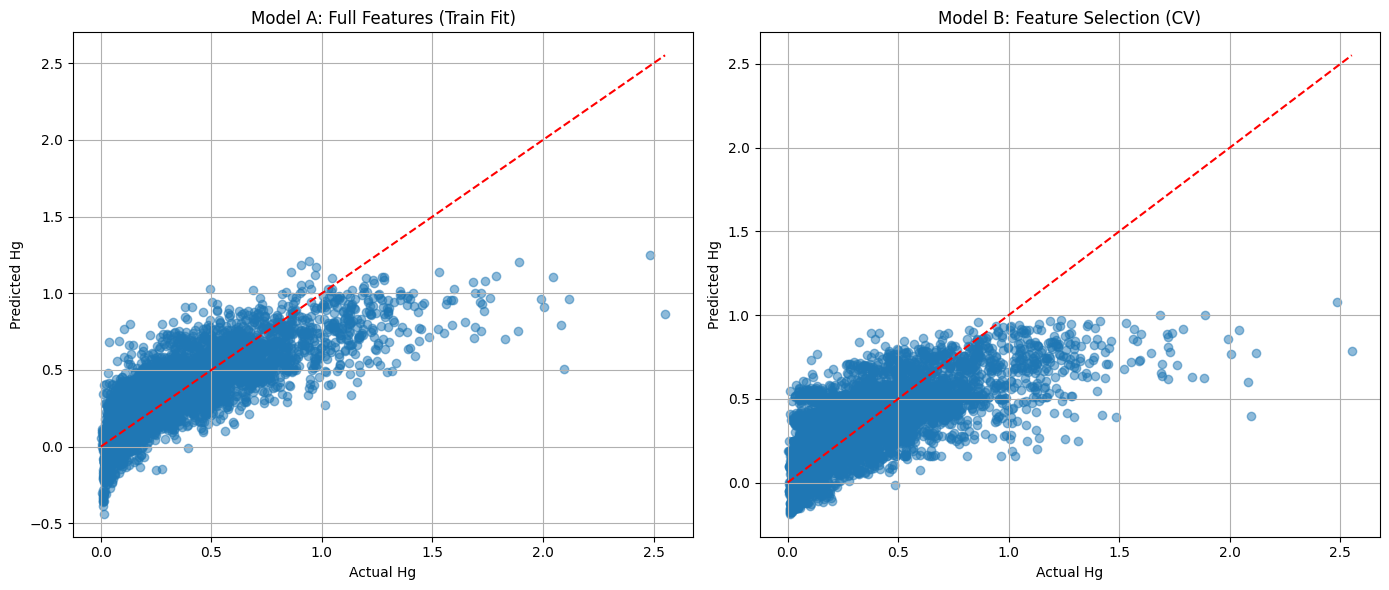

In [71]:
# Compare Actual_Hg to Predicted for Model A vs Model B

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Model A (training fit) ---
axes[0].scatter(y, y_pred_cv_a, alpha=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set_title("Model A: Full Features (Train Fit)")
axes[0].set_xlabel("Actual Hg")
axes[0].set_ylabel("Predicted Hg")
axes[0].grid(True)

# --- Model B (CV predictions) ---
axes[1].scatter(y, y_pred_lr, alpha=0.5)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[1].set_title("Model B: Feature Selection (CV)")
axes[1].set_xlabel("Actual Hg")
axes[1].set_ylabel("Predicted Hg")
axes[1].grid(True)

plt.tight_layout()
plt.show()

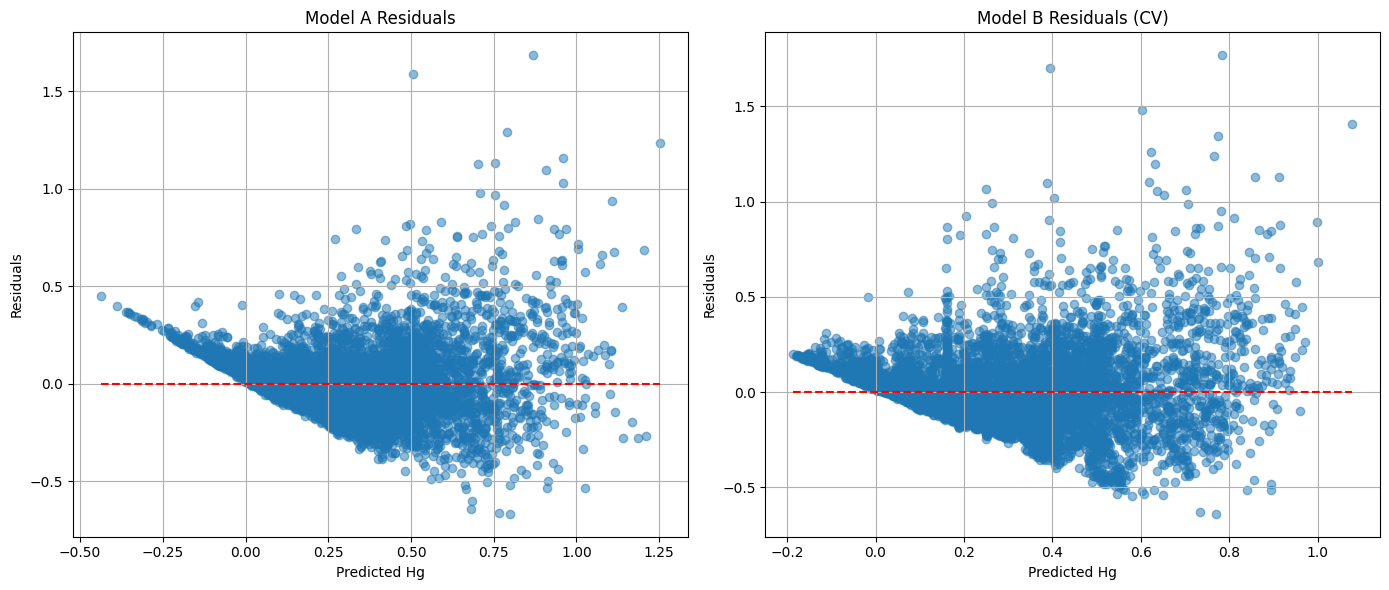

In [72]:
# Compare Residuals: Model A vs Model B

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Model A residuals
axes[0].scatter(y_pred_cv_a, y - y_pred_cv_a, alpha=0.5)
axes[0].hlines(0, y_pred_cv_a.min(), y_pred_cv_a.max(), colors='red', linestyles='dashed')
axes[0].set_title("Model A Residuals")
axes[0].set_xlabel("Predicted Hg")
axes[0].set_ylabel("Residuals")
axes[0].grid(True)

# Model B residuals
axes[1].scatter(y_pred_lr, y - y_pred_lr, alpha=0.5)
axes[1].hlines(0, y_pred_lr.min(), y_pred_lr.max(), colors='red', linestyles='dashed')
axes[1].set_title("Model B Residuals (CV)")
axes[1].set_xlabel("Predicted Hg")
axes[1].set_ylabel("Residuals")
axes[1].grid(True)

plt.tight_layout()
plt.show()

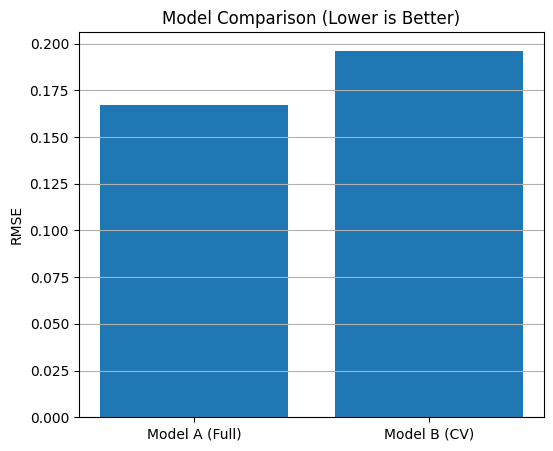

In [73]:
# Compare RMSE for Model A vs Model B

from sklearn.metrics import mean_squared_error

rmse_a = np.sqrt(mean_squared_error(y, y_pred_cv_a))
rmse_b = np.sqrt(mean_squared_error(y, y_pred_lr))

models = ['Model A (Full)', 'Model B (CV)']
rmse_vals = [rmse_a, rmse_b]

plt.figure(figsize=(6, 5))
plt.bar(models, rmse_vals)
plt.ylabel("RMSE")
plt.title("Model Comparison (Lower is Better)")
plt.grid(axis='y')
plt.show()

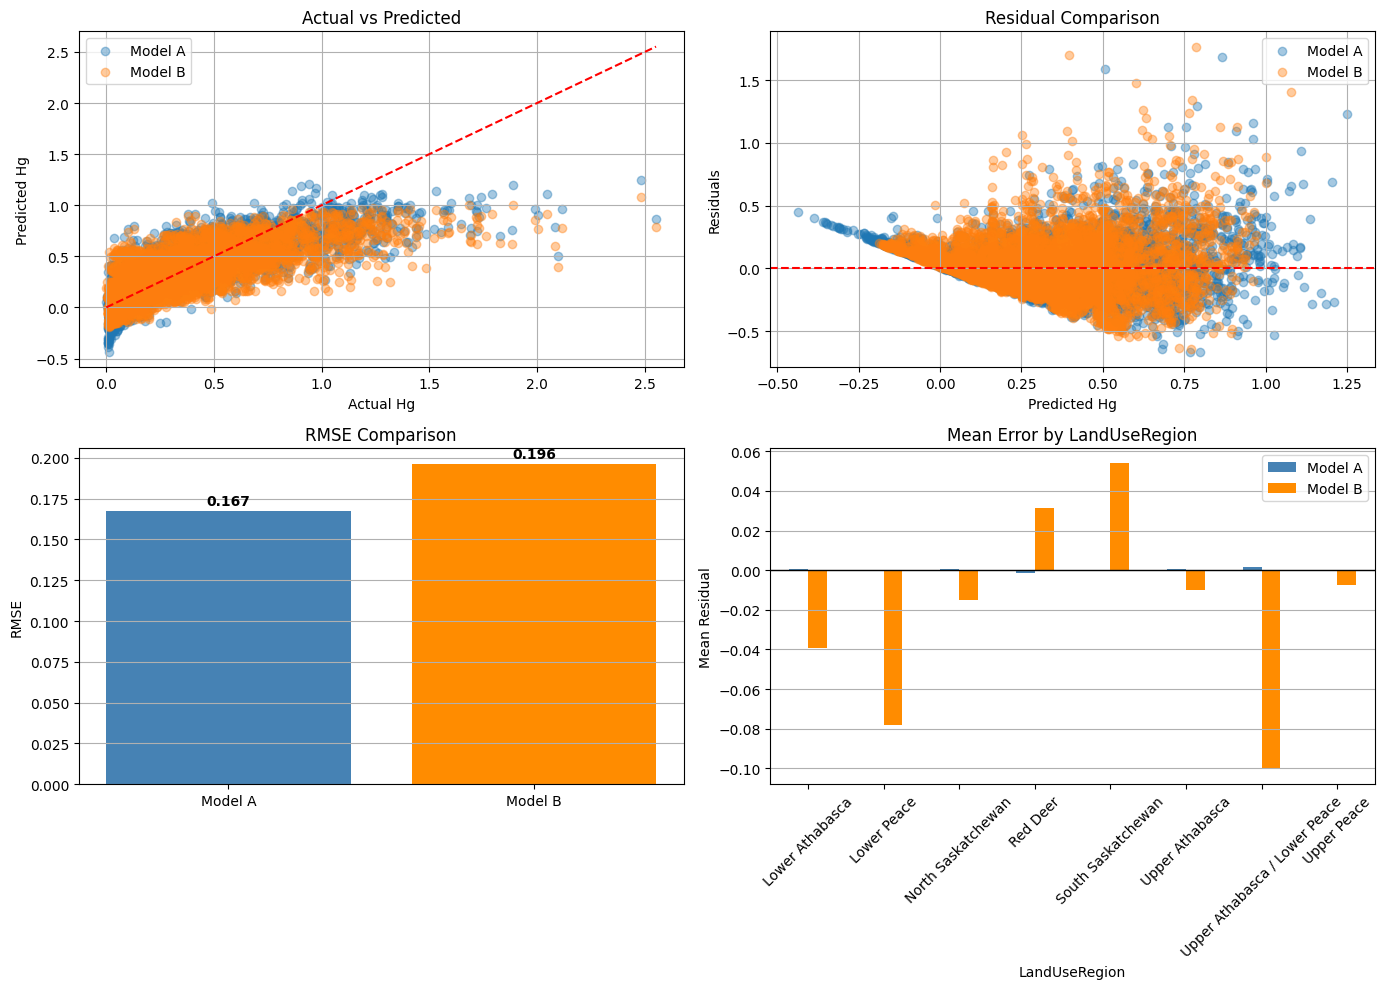

In [74]:
# Compare Model A vs Model B - Combined



# Choose grouping variable
group_var = "LandUseRegion"  # change anytime


# Build comparison dataframe
temp = pd.DataFrame({
    group_var: fish[group_var].fillna("Unknown"),
    "Actual": y,
    "Err_A": y - y_pred_cv_a,
    "Err_B": y - y_pred_lr
})

grouped = temp.groupby(group_var)[["Err_A", "Err_B"]].mean()


# RMSE values
rmse_a = np.sqrt(mean_squared_error(y, y_pred_cv_a))
rmse_b = np.sqrt(mean_squared_error(y, y_pred_lr))

models = ["Model A", "Model B"]
rmse_vals = [rmse_a, rmse_b]


# Create figure (ONLY ONE SYSTEM)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# 1. Actual vs Predicted
axes[0, 0].scatter(y, y_pred_cv_a, alpha=0.4, label="Model A")
axes[0, 0].scatter(y, y_pred_lr, alpha=0.4, label="Model B")
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0, 0].set_title("Actual vs Predicted")
axes[0, 0].set_xlabel("Actual Hg")
axes[0, 0].set_ylabel("Predicted Hg")
axes[0, 0].legend()
axes[0, 0].grid(True)


# 2. Residual comparison
axes[0, 1].scatter(y_pred_cv_a, y - y_pred_cv_a, alpha=0.4, label="Model A")
axes[0, 1].scatter(y_pred_lr, y - y_pred_lr, alpha=0.4, label="Model B")
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Residual Comparison")
axes[0, 1].set_xlabel("Predicted Hg")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].legend()
axes[0, 1].grid(True)


# 3. RMSE comparison (FIXED + CLEAN)
bars = axes[1, 0].bar(models, rmse_vals, color=["steelblue", "darkorange"])
axes[1, 0].set_title("RMSE Comparison")
axes[1, 0].set_ylabel("RMSE")
axes[1, 0].grid(axis="y")

# Add labels on bars
for bar, value in zip(bars, rmse_vals):
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01 * max(rmse_vals),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# 4. Group-level error comparison

grouped = grouped.rename(columns={ # Rename columns for clean legend
    "Err_A": "Model A",
    "Err_B": "Model B"
})


# Plot: Mean Error by Region
grouped.plot(
    kind="bar",
    ax=axes[1, 1],
    color={
        "Model A": "steelblue",
        "Model B": "darkorange"
    }
)

# Horizontal zero line
axes[1, 1].axhline(0, color="black", linewidth=1)

# Labels and title
axes[1, 1].set_title(f"Mean Error by {group_var}")
axes[1, 1].set_ylabel("Mean Residual")
axes[1, 1].set_xlabel(group_var)

# Grid for readability
axes[1, 1].grid(axis="y")

# Rotate x labels (optional but recommended)
axes[1, 1].tick_params(axis='x', rotation=45)

# Final layout
plt.tight_layout()
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Model A and B - Model Comparison
</span>

<span style="color: #d2b075; font-size: 16px;text-decoration: underline">Actual vs Predicted</span><br>
- Model A shows a tighter alignment to the 45° line than Model B, indicating better predictive accuracy. 
- Both models still underpredict high mercury values (points flatten below the line at larger Hg), revealing a shared limitation in capturing extreme values.

<span style="color: #d2b075; font-size: 16px;text-decoration: underline">Residual Comparison</span><br>
- Both models exhibit a clear funnel shape in the residuals, indicating heteroskedasticity.
- Model A shows a slightly tighter and more centered spread around zero compared to Model B, suggesting more stable error behavior.

<span style="color: #d2b075; font-size: 16px;text-decoration: underline">RMSE Comparison</span><br>
- Model A achieves a lower RMSE than Model B, indicating better overall predictive accuracy and confirming that the full feature model performs more effectively.

<span style="color: #d2b075; font-size: 16px;text-decoration: underline">Mean Error by LandUseRegion Comparison</span><br>
- Model B shows a pronounced negative bias in various regions, while Model A remains closer to zero across regions, indicating more consistent and less region-specific error.



</span>
</div>


<div style="border: 2px solid yellow; padding: 10px; border-radius: 8px;">
<span style="color: yellow;">Model C - Random Forest regression with leakage-safe lake-averaged feature and 5-fold cross-validation. </span>


Model Characteristics
- Random Forest Regression inside a Pipeline
- Builds a full pipeline-based Random Forest regressor --> chains feature engineering, preprocessing, and modeling together, uses 200 trees
- Includes a custom transformer that computes a leakage-safe lake-level average mercury feature -> calculates average Hg for each waterbody using only the training fold
- Combines fish-level, lake-level, and imputation flags --> uses size, age, lake count, grouped waterbody indicators, and imputation markers as numeric inputs
- Treats categorical variables with proper one-hot encoding --> encodes species, sex, maturity, waterbody type, land use region, and waterbody age information
- Validates properly with 5-fold cross-validation --> evaluates RMSE and R² on unseen folds rather than training data
- Generates cross-validated predictions for diagnostics 


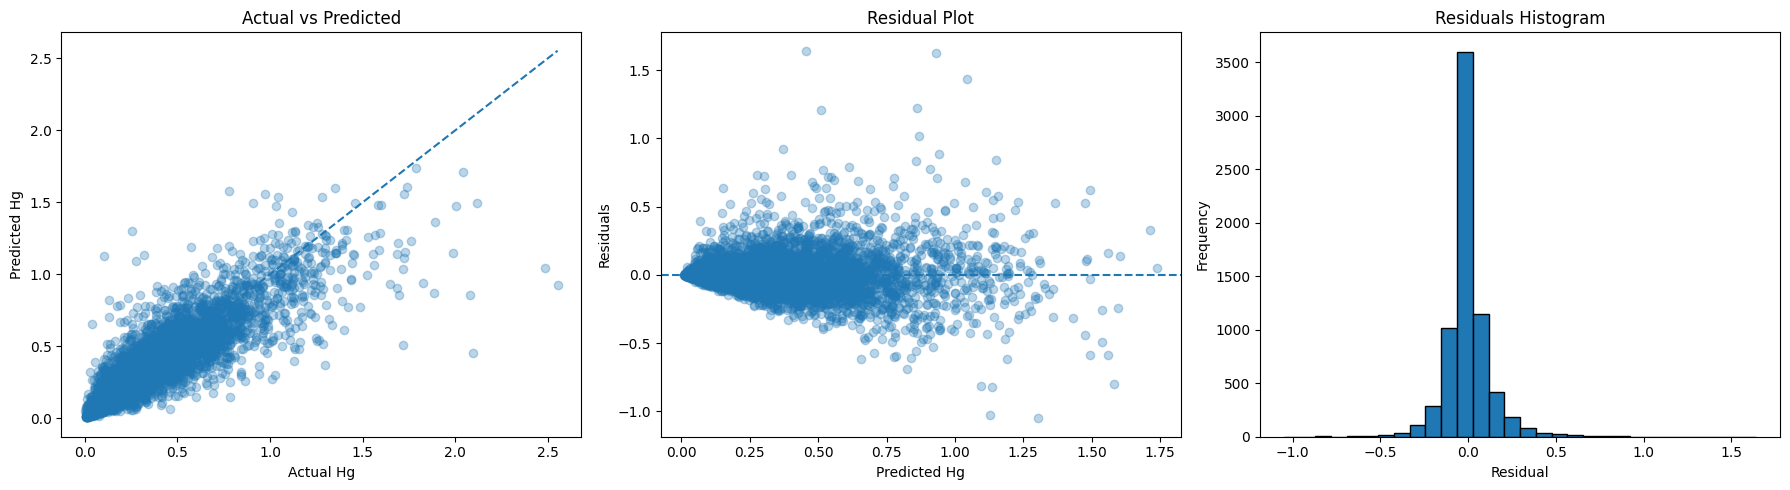

RMSE: 0.133 ± 0.007
R²:   0.787 ± 0.016


In [75]:
# Model C - Random Forest regression with leakage-safe lake-averaged feature and 5-fold cross-validation.


# Step 1 - Create function to calculate average mercury for each waterbody for the training data
class LakeAvgTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, lake_col='WaterbodyName', target_col='Hg'):
        self.lake_col = lake_col
        self.target_col = target_col

    def fit(self, X, y):
        df = X.copy()
        df[self.target_col] = y
        
        # compute lake avg ONLY on training fold
        self.lake_avg_ = df.groupby(self.lake_col)[self.target_col].mean()
        self.global_mean_ = y.mean()
        return self

    def transform(self, X):
        X = X.copy()
        X['Lake_Hg_Avg_CV'] = X[self.lake_col].map(self.lake_avg_)
        
        # fill unseen lakes with global mean
        X['Lake_Hg_Avg_CV'] = X['Lake_Hg_Avg_CV'].fillna(self.global_mean_)
        
        return X


# Step 2 - Define columns
bool_cols = [
    'Age_imputed',
    'Sex_imputed',
    'Waterbody_grouped_Lac Ste. Anne',
    'Waterbody_grouped_Lac la Nonne',
    'Waterbody_grouped_Other',
    'Waterbody_grouped_Other_Lakes',
    'Waterbody_grouped_Pine Coulee Reservoir',
    'Waterbody_grouped_Red Deer River (near Blindman River Mouth)',
    'Waterbody_grouped_Twin Valley Reservoir'
]

numeric_cols = [
    'ForkLength',
    'Weight',
    'Age',
    'Lake_Count'
] + bool_cols

categorical_cols = [
    'CommonName',
    'Sex',
    'Maturity',
    'WaterbodyType',
    'LandUseRegion',
    'Waterbody_age_mean'
]


# Step 3 - One Hot encode the categorical columns, passthrough the numeric
preprocessor = ColumnTransformer([
    ('num', 'passthrough', numeric_cols + ['Lake_Hg_Avg_CV']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


# Step 4 - Full pipeline
pipeline = Pipeline([
    ('lake_avg', LakeAvgTransformer()),   # creates leakage-safe Lake_Hg_Avg
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


# Step 5 - Run cross-validation
X = fish.drop(columns=['Hg'])
y = fish['Hg']

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

rmse_mean_rf = -scores.mean()
rmse_std_rf = scores.std()

# R²
r2_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='r2'
)

r2_mean_rf = r2_scores.mean()
r2_std_rf = r2_scores.std()


# Step 6 - Get cross-validated predictions
y_pred_rf = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)


# Step 7 - Residuals
residuals = y - y_pred_rf


# Step 8 - Plots in a grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- Actual vs Predicted ----
axes[0].scatter(y, y_pred_rf, alpha=0.3)

# Perfect prediction line
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], linestyle='--')

axes[0].set_xlabel("Actual Hg")
axes[0].set_ylabel("Predicted Hg")
axes[0].set_title("Actual vs Predicted")

# ---- Residual Plot ----
axes[1].scatter(y_pred_rf, residuals, alpha=0.3)
axes[1].axhline(y=0, linestyle='--')

axes[1].set_xlabel("Predicted Hg")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

# ---- Histogram of Residuals ----
axes[2].hist(residuals, bins=30, edgecolor='black')

axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Residuals Histogram")

# Layout fix
plt.tight_layout()
plt.show()


# Print both
print(f"RMSE: {rmse_mean_rf:.3f} ± {rmse_std_rf:.3f}")
print(f"R²:   {r2_mean_rf:.3f} ± {r2_std_rf:.3f}")

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Model C - Random Forest Regressor - Plot Analysis
</span>

RMSE: 0.133 ± 0.007<br>
R²:   0.787 ± 0.016

1. Model captures general trend but underestimates extremes
    - In the Actual vs Predicted plot, predictions follow the diagonal trend, which is good.
    - However, for higher Hg values, predictions tend to fall below the line → the model underpredicts high mercury levels.
2. Predictions are compressed (regression to the mean)
    - The spread of predicted values is narrower than actual values.
    - This is typical for Random Forests — they smooth predictions and struggle to extrapolate extremes.
3. Heteroscedasticity is present (non-constant variance)
    - In the residual plot, the spread of residuals increases as predicted Hg increases.
    - This “fan shape” indicates errors grow for larger values, meaning the model is less reliable at higher Hg levels.
4. Residuals are centered around zero (good sign)
    - The residuals are roughly balanced above and below zero.
    - This suggests no major systematic bias overall (the model isn’t consistently over- or under-predicting across all values).
5. Residual distribution is roughly normal but slightly skewed
    - The histogram is centered near 0, which is ideal.
    - There may be a slight right skew (longer positive tail), indicating occasional underpredictions of high Hg values.
6. Presence of outliers / large errors
    - Some residuals are quite large (both positive and negative).
    - This suggests that certain observations are hard to predict, or there may be missing features (e.g., environmental factors, location effects) not fully captured

</span>
</div>

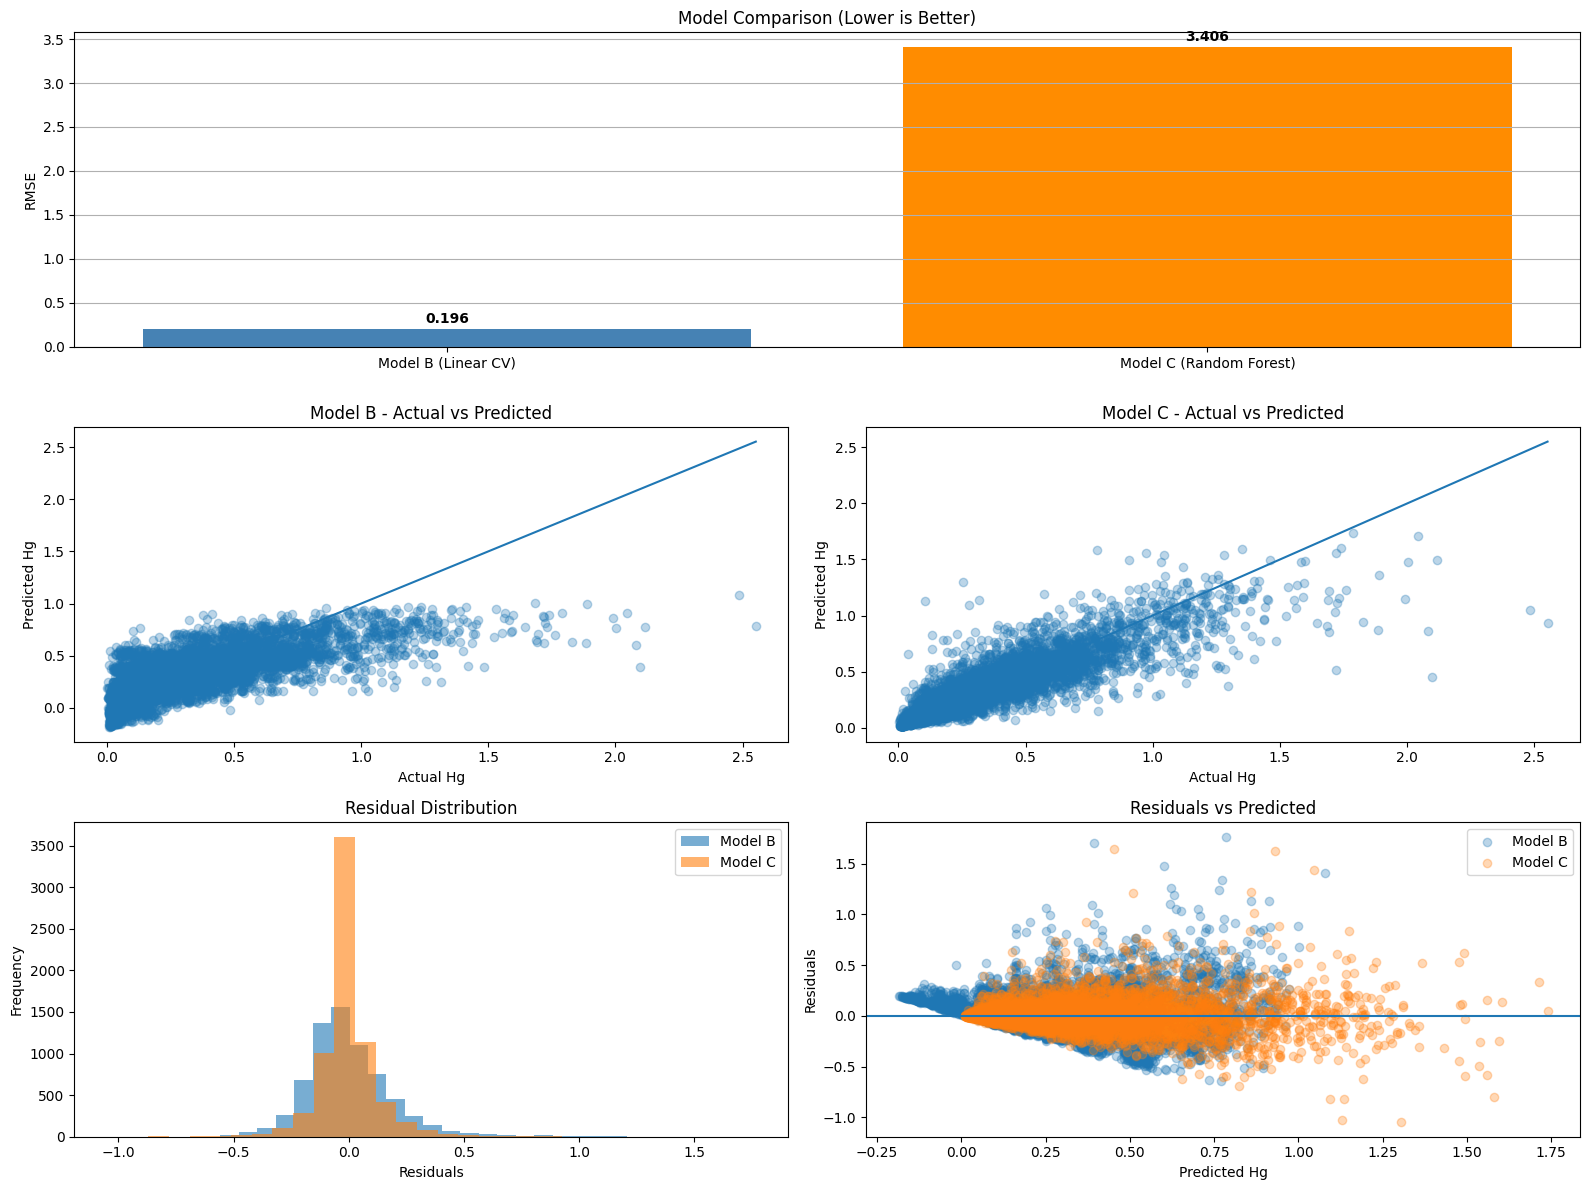

In [76]:
# Lets Compare Model B (Linear Regression Feature Selection and CV)   to Model C (Random Forest Regressor)


# 1. Residuals
residuals_b = y - y_pred_lr
residuals_c = y - y_pred_rf


# 2. RMSE values
rmse_vals = [rmse_b, rmse_mean]
models = ['Model B (Linear CV)', 'Model C (Random Forest)']


# 3. Create figure layout
fig = plt.figure(figsize=(16, 12))


# RMSE Bar Chart
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)
colors = ['steelblue', 'darkorange'] 
bars = ax1.bar(models, rmse_vals, color=colors)
ax1.set_ylabel("RMSE")
ax1.set_title("Model Comparison (Lower is Better)")
ax1.grid(axis='y')


# ADD RMSE LABELS ON TOP OF BARS
for bar, value in zip(bars, rmse_vals):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01 * max(rmse_vals),
        f"{value:.3f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )



# Actual vs Predicted
ax2 = plt.subplot2grid((3, 2), (1, 0))
ax2.scatter(y, y_pred_lr, alpha=0.3)
ax2.plot([y.min(), y.max()], [y.min(), y.max()])
ax2.set_title("Model B - Actual vs Predicted")
ax2.set_xlabel("Actual Hg")
ax2.set_ylabel("Predicted Hg")

ax3 = plt.subplot2grid((3, 2), (1, 1))
ax3.scatter(y, y_pred_rf, alpha=0.3)
ax3.plot([y.min(), y.max()], [y.min(), y.max()])
ax3.set_title("Model C - Actual vs Predicted")
ax3.set_xlabel("Actual Hg")
ax3.set_ylabel("Predicted Hg")


# Residual Histograms
ax4 = plt.subplot2grid((3, 2), (2, 0))
ax4.hist(residuals_b, bins=30, alpha=0.6, label='Model B')
ax4.hist(residuals_c, bins=30, alpha=0.6, label='Model C')
ax4.set_title("Residual Distribution")
ax4.set_xlabel("Residuals")
ax4.set_ylabel("Frequency")
ax4.legend()


# Residuals vs Predicted
ax5 = plt.subplot2grid((3, 2), (2, 1))
ax5.scatter(y_pred_lr, residuals_b, alpha=0.3, label='Model B')
ax5.scatter(y_pred_rf, residuals_c, alpha=0.3, label='Model C')
ax5.axhline(0)
ax5.set_title("Residuals vs Predicted")
ax5.set_xlabel("Predicted Hg")
ax5.set_ylabel("Residuals")
ax5.legend()

plt.tight_layout()
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Model B (LR) vs Model C (RF)
</span>

The Random Forest model significantly improves predictive accuracy and captures nonlinear patterns, though both models exhibit increased error and underprediction at higher mercury levels.

1. Random Forest clearly outperforms Linear Regression
    - RMSE drops from 0.207 (Model B) to 0.133 (Model C)
    - This is a substantial improvement (~36% reduction in error), showing the Random Forest captures the data structure much better.
2. Linear model severely underfits the data
    - In Model B (bottom-left), predictions are compressed into a narrow band
    - It fails to capture variability, especially at higher Hg levels → classic underfitting
3. Random Forest better captures nonlinear relationships
    - Model C’s scatter follows the diagonal much more closely
    - Indicates it is capturing nonlinear patterns (likely from fish size, lake effects, etc.) that linear regression cannot
4. Both models struggle with high Hg values
    - Even in Model C, predictions fall below the line at high values
    - This suggests a limited signal in features for extreme Hg, or natural difficulty predicting rare high values
5. Residual spread is much tighter for Random Forest
    - Histogram shows Model C residuals are more concentrated around 0
    - Model B has a wider spread, meaning more frequent large errors
6. Heteroscedasticity still exists (especially in RF)
    - Residuals vs Predicted shows a fan shape, especially for Model C
    - Errors increase as predicted Hg increases → model is less reliable at higher values

</span>
</div>


<div style="border: 2px solid yellow; padding: 10px; border-radius: 8px;">
<span style="color: yellow;">Model D - LightGBM </span>


Model Characteristics
- Engineer a strong location-based feature --> average mercury per waterbody (captures environmental signal)
- Uses a powerful nonlinear model --> LightGBM gradient boosting
- Combines mixed feature types in a pipeline
- Validates properly with cross-validation
- Generates out-of-fold predictions for diagnostics



Model D - LightGBM (Best Practice)
-----------------------------------
RMSE: 0.131 ± 0.007
R²:   0.794 ± 0.018


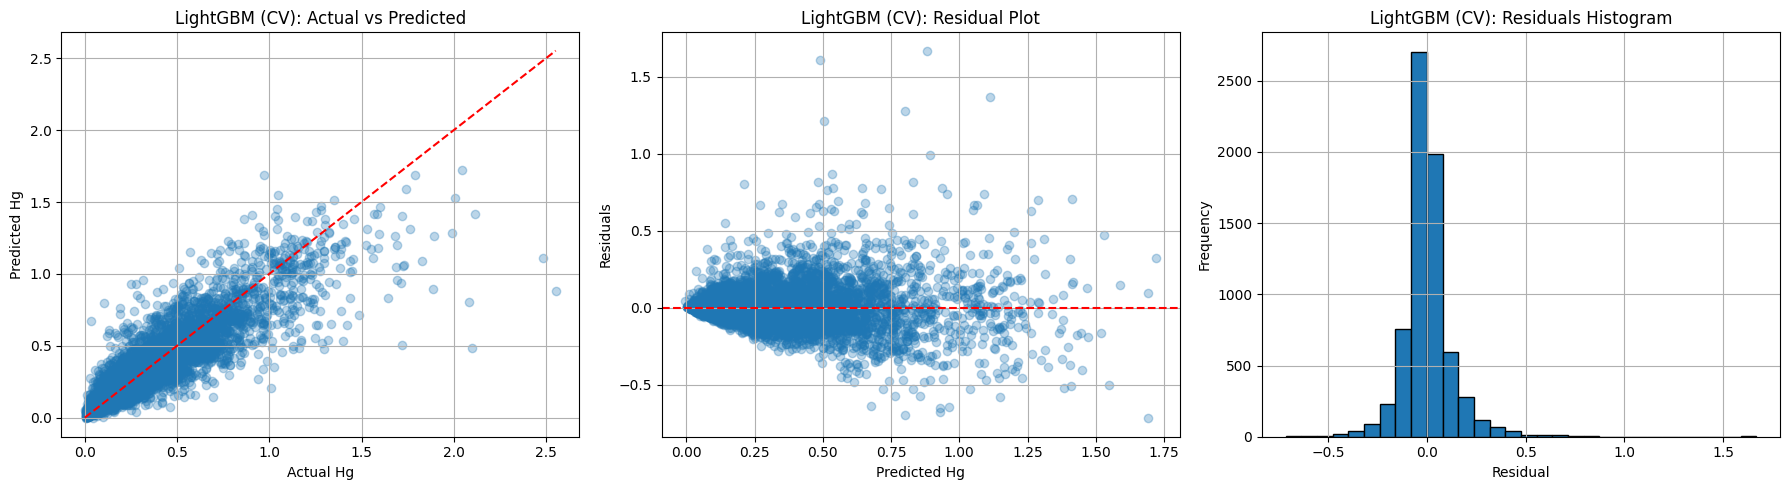

In [78]:
# Model D - LightGBM gradient boosting model trained with cross-validation for nonlinear prediction.

# 1. Suppress warnings (clean output)
import warnings
warnings.filterwarnings("ignore")


# 2. Lake feature transformer (leakage-safe)
class LakeAvgTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, lake_col='WaterbodyName', target_col='Hg'):
        self.lake_col = lake_col
        self.target_col = target_col

    def fit(self, X, y):
        df = X.copy()
        df[self.target_col] = y

        self.lake_avg_ = df.groupby(self.lake_col)[self.target_col].mean()
        self.global_mean_ = y.mean()
        return self

    def transform(self, X):
        X = X.copy()
        X['Lake_Hg_Avg_CV'] = X[self.lake_col].map(self.lake_avg_)
        X['Lake_Hg_Avg_CV'] = X['Lake_Hg_Avg_CV'].fillna(self.global_mean_)
        return X


# 3. Data
X = fish.drop(columns=['Hg'])
y = fish['Hg']


# 4. Column setup
bool_cols = [
    'Age_imputed',
    'Sex_imputed',
    'Waterbody_grouped_Lac Ste. Anne',
    'Waterbody_grouped_Lac la Nonne',
    'Waterbody_grouped_Other',
    'Waterbody_grouped_Other_Lakes',
    'Waterbody_grouped_Pine Coulee Reservoir',
    'Waterbody_grouped_Red Deer River (near Blindman River Mouth)',
    'Waterbody_grouped_Twin Valley Reservoir'
]

numeric_cols = [
    'ForkLength',
    'Weight',
    'Age',
    'Lake_Count'
] + bool_cols + ['Lake_Hg_Avg_CV']

categorical_cols = [
    'CommonName',
    'Sex',
    'Maturity',
    'WaterbodyType',
    'LandUseRegion',
    'Waterbody_age_mean'
]


# 5. Preprocessing (no feature-name issues)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)


# 6. LightGBM model (clean + stable)
lgbm = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


# 7. Full pipeline
pipeline_lgbm = Pipeline([
    ('lake_avg', LakeAvgTransformer()),
    ('prep', preprocessor),
    ('model', lgbm)
])


# 8. Cross-validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)


# 9. Evaluation (RMSE + R2)
rmse_scores = cross_val_score(
    pipeline_lgbm,
    X,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

r2_scores = cross_val_score(
    pipeline_lgbm,
    X,
    y,
    cv=cv,
    scoring='r2'
)

rmse_mean_lgbm = -rmse_scores.mean()
rmse_std_lgbm = rmse_scores.std()

r2_mean_lgbm = r2_scores.mean()
r2_std_lgbm = r2_scores.std()

print("Model D - LightGBM (Best Practice)")
print("-----------------------------------")
print(f"RMSE: {rmse_mean_lgbm:.3f} ± {rmse_std_lgbm:.3f}")
print(f"R²:   {r2_mean_lgbm:.3f} ± {r2_std_lgbm:.3f}")


# 10. Cross-validated predictions
y_pred_lgbm = cross_val_predict(
    pipeline_lgbm,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

residuals = y - y_pred_lgbm


# 11. Plots in a grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- Actual vs Predicted ----
axes[0].scatter(y, y_pred_lgbm, alpha=0.3)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

axes[0].set_xlabel("Actual Hg")
axes[0].set_ylabel("Predicted Hg")
axes[0].set_title("LightGBM (CV): Actual vs Predicted")
axes[0].grid(True)

# ---- Residual Plot ----
axes[1].scatter(y_pred_lgbm, residuals, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--')

axes[1].set_xlabel("Predicted Hg")
axes[1].set_ylabel("Residuals")
axes[1].set_title("LightGBM (CV): Residual Plot")
axes[1].grid(True)

# ---- Residual Histogram ----
axes[2].hist(residuals, bins=30, edgecolor='black')

axes[2].set_xlabel("Residual")
axes[2].set_ylabel("Frequency")
axes[2].set_title("LightGBM (CV): Residuals Histogram")
axes[2].grid(True)

plt.tight_layout()
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Model D Light GBM - Plot Analysis
</span>

The LightGBM model provides a strong fit and captures nonlinear relationships effectively, though it exhibits increasing error and slight underprediction at higher mercury levels.<br><br>
The RMSE: 0.131 ± 0.007<br>
R²:   0.794 ± 0.018<br>

1. Strong overall fit to the data
    - In the Actual vs Predicted plot, points closely follow the diagonal line.
    - This indicates the model is capturing the underlying relationship well.
2. Better spread of predictions than simpler models
    - Predictions cover a wider range of Hg values compared to linear models.
    - Suggests LightGBM is effectively modeling nonlinear patterns and interactions.
3. Slight underprediction at higher Hg levels
    - At the upper end, predictions fall below the diagonal line.
    - Indicates the model still struggles with extreme mercury values.
4. Residuals are centered around zero
    - Residual plot shows errors distributed around the zero line.
    - This suggests no strong overall bias in predictions.
5. Heteroscedasticity is present
    - Residual spread increases as predicted Hg increases (fan shape).
    - Model is less precise for higher mercury values.
6. Residual distribution is mostly normal with some skew
    - Histogram is centered near zero, which is ideal.
    - Slight skew or tails indicate occasional larger prediction errors, especially for extreme cases.

</span>
</div>

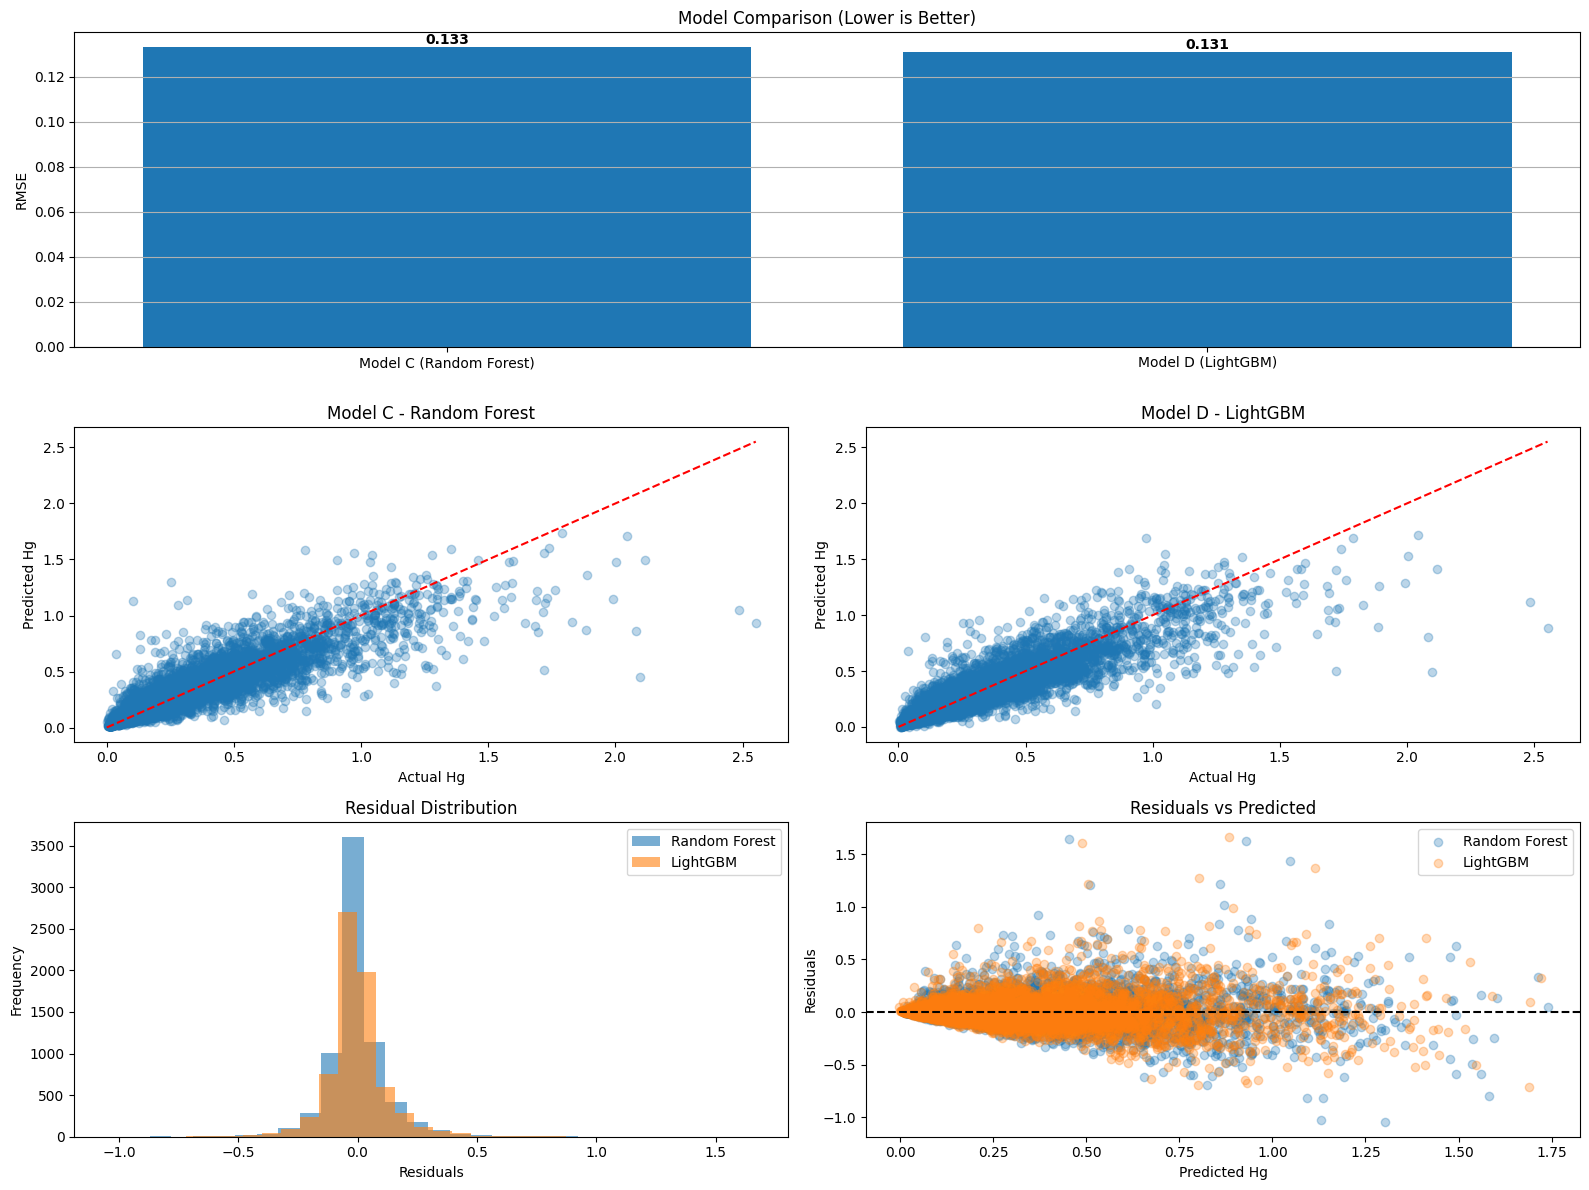

In [79]:
# Compare Models C (RF) and D (LGBM)


# 1. Residuals
residuals_c = y - y_pred_rf
residuals_d = y - y_pred_lgbm


# 2. RMSE values
rmse_vals = [rmse_mean_rf, rmse_mean_lgbm]
models = ['Model C (Random Forest)', 'Model D (LightGBM)']


# 3. Figure layout
fig = plt.figure(figsize=(16, 12))


# RMSE BAR CHART
ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)

bars = ax1.bar(models, rmse_vals)

ax1.set_ylabel("RMSE")
ax1.set_title("Model Comparison (Lower is Better)")
ax1.grid(axis='y')


# ADD RMSE LABELS ON TOP OF BARS
for bar, value in zip(bars, rmse_vals):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )


# ACTUAL vs PREDICTED
ax2 = plt.subplot2grid((3, 2), (1, 0))
ax2.scatter(y, y_pred_rf, alpha=0.3)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax2.set_title("Model C - Random Forest")
ax2.set_xlabel("Actual Hg")
ax2.set_ylabel("Predicted Hg")

ax3 = plt.subplot2grid((3, 2), (1, 1))
ax3.scatter(y, y_pred_lgbm, alpha=0.3)
ax3.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
ax3.set_title("Model D - LightGBM")
ax3.set_xlabel("Actual Hg")
ax3.set_ylabel("Predicted Hg")


# RESIDUAL DISTRIBUTION
ax4 = plt.subplot2grid((3, 2), (2, 0))
ax4.hist(residuals_c, bins=30, alpha=0.6, label='Random Forest')
ax4.hist(residuals_d, bins=30, alpha=0.6, label='LightGBM')
ax4.set_title("Residual Distribution")
ax4.set_xlabel("Residuals")
ax4.set_ylabel("Frequency")
ax4.legend()


# RESIDUALS vs PREDICTED
ax5 = plt.subplot2grid((3, 2), (2, 1))
ax5.scatter(y_pred_rf, residuals_c, alpha=0.3, label='Random Forest')
ax5.scatter(y_pred_lgbm, residuals_d, alpha=0.3, label='LightGBM')
ax5.axhline(0, color='black', linestyle='--')
ax5.set_title("Residuals vs Predicted")
ax5.set_xlabel("Predicted Hg")
ax5.set_ylabel("Residuals")
ax5.legend()

plt.tight_layout()
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Compare Model C (RF) with Model D (LGBM) - Plot Analysis
</span>

While both models perform well, LightGBM provides a marginal improvement in accuracy and error consistency, though both models exhibit increased uncertainty at higher mercury levels<br><br>


1. LightGBM slightly outperforms Random Forest
    - RMSE: 0.131 (LightGBM) vs 0.133 (Random Forest)
    - The improvement is small but consistent → LightGBM is the best-performing model overall
2. Both models capture the general relationship well
    - In both scatter plots, predictions follow the diagonal trend
    - Indicates both models successfully learn the core relationship between features and Hg
3. LightGBM provides a tighter fit
    - The LightGBM plot (right) shows points more closely aligned to the diagonal
    - Suggests slightly better accuracy and less dispersion of errors
4. Residual distributions are centered but LightGBM is more concentrated
    - Both models have residuals centered around 0 (good)
    - LightGBM’s distribution is slightly narrower, indicating fewer large errors
5. Both models show increasing error at higher values
    - Residuals vs Predicted plot shows a fan shape for both models
    - Errors increase with Hg → both models are less reliable for high mercury levels

</span>
</div>

<div style="border: 2px solid; color: #7FDBFF; padding: 10px; border-radius: 8px; font-size: 30px">
<span style="color: #7FDBFF;">
  Section 8 - Conclusion
</span>
</div>

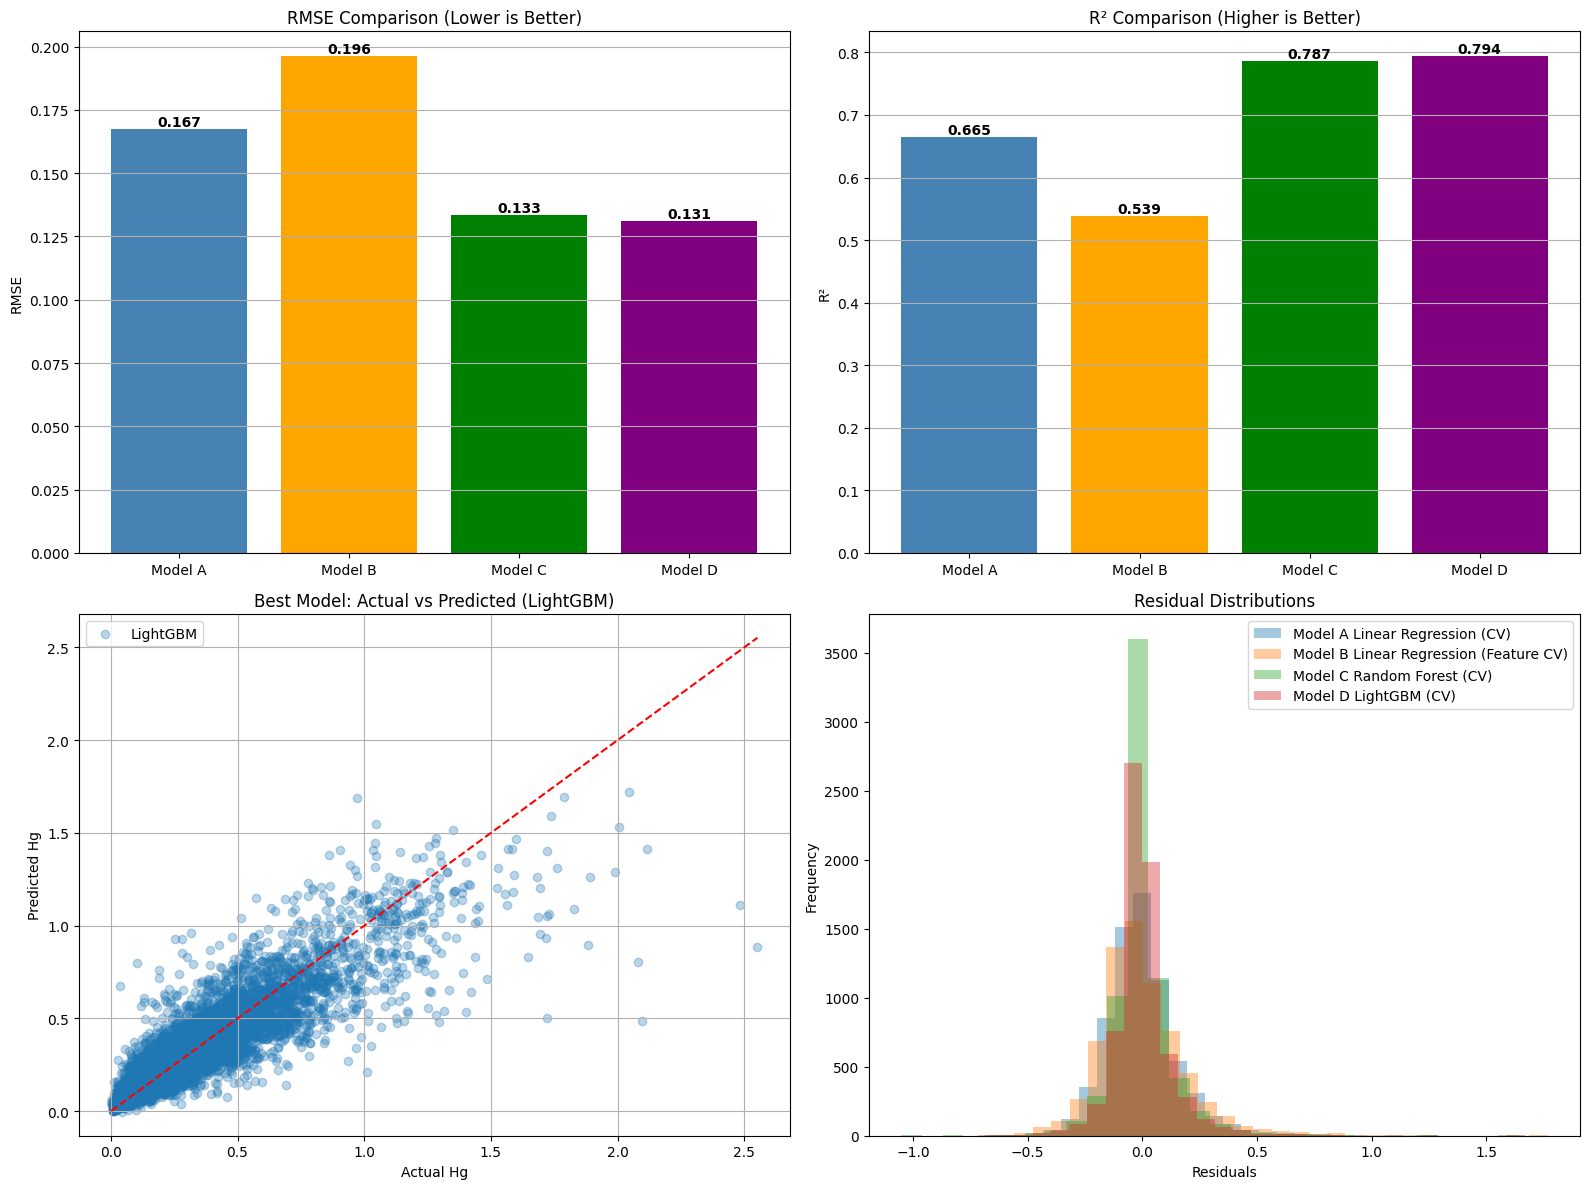

In [80]:
# Lets compare the 4 Models


# 1. Compute metrics 
rmse_a = np.sqrt(mean_squared_error(y, y_pred_cv_a))
rmse_b = np.sqrt(mean_squared_error(y, y_pred_lr))
rmse_c = np.sqrt(mean_squared_error(y, y_pred_rf))
rmse_d = rmse_mean_lgbm  # from CV results

r2_a = r2_score(y, y_pred_cv_a)
r2_b = r2_score(y, y_pred_lr)
r2_c = r2_score(y, y_pred_rf)
r2_d = r2_mean_lgbm

models = ["Model A", "Model B", "Model C", "Model D"]

rmse_vals = [rmse_a, rmse_b, rmse_c, rmse_d]
r2_vals = [r2_a, r2_b, r2_c, r2_d]


# 2. Residuals
res_a = y - y_pred_cv_a
res_b = y - y_pred_lr
res_c = y - y_pred_rf
res_d = y - y_pred_lgbm


# 3. Figure layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# RMSE comparison
bars = axes[0, 0].bar(models, rmse_vals,
                      color=["steelblue", "orange", "green", "purple"])

axes[0, 0].set_title("RMSE Comparison (Lower is Better)")
axes[0, 0].set_ylabel("RMSE")
axes[0, 0].grid(axis="y")

for bar, val in zip(bars, rmse_vals):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


# R² comparison
bars2 = axes[0, 1].bar(models, r2_vals,
                       color=["steelblue", "orange", "green", "purple"])

axes[0, 1].set_title("R² Comparison (Higher is Better)")
axes[0, 1].set_ylabel("R²")
axes[0, 1].grid(axis="y")

for bar, val in zip(bars2, r2_vals):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )


# Actual vs Predicted (BEST MODEL = LightGBM)
axes[1, 0].scatter(y, y_pred_lgbm, alpha=0.3, label="LightGBM")

axes[1, 0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")

axes[1, 0].set_title("Best Model: Actual vs Predicted (LightGBM)")
axes[1, 0].set_xlabel("Actual Hg")
axes[1, 0].set_ylabel("Predicted Hg")
axes[1, 0].legend()
axes[1, 0].grid(True)


# Residual distributions
axes[1, 1].hist(res_a, bins=30, alpha=0.4, label="Model A Linear Regression (CV)")
axes[1, 1].hist(res_b, bins=30, alpha=0.4, label="Model B Linear Regression (Feature CV)")
axes[1, 1].hist(res_c, bins=30, alpha=0.4, label="Model C Random Forest (CV)")
axes[1, 1].hist(res_d, bins=30, alpha=0.4, label="Model D LightGBM (CV)")

axes[1, 1].set_title("Residual Distributions")
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

<div style="border: 2px solid red; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Compare Models A, B, C, D - Plot Analysis
</span>


1. All models perform within a relatively close range
    - The RMSE values are fairly similar across models.
    - This suggests that feature engineering and data quality may be limiting performance gains, rather than model choice alone.
2. LightGBM achieves the lowest error
    - Model D slightly outperforms the others with the lowest RMSE.
    - Indicates it is the most accurate model, though the improvement is incremental.
3. Tree-based models outperform linear models
    - Models C (Random Forest) and D (LightGBM) generally perform better than Models A and B.
    - Confirms that the relationship between features and Hg is nonlinear.
4. Performance differences are small → model stability matters
    - Since RMSE differences are small, factors like: consistency (std dev), interpretability, and robustness become more important when selecting the final model.


Final Model Selection

Among the four models tested, Model D (LightGBM) was selected as the final model based on overall predictive performance and consistency. While both Model C (Random Forest) and Model D demonstrated strong ability to capture nonlinear relationships in the data, LightGBM achieved the lowest RMSE, indicating the most accurate predictions on average. Additionally, its residuals were more tightly concentrated around zero, suggesting improved error consistency compared to the other models.

In contrast, the linear models (Model A and Model B) showed clear limitations. Model A underfit the data by failing to capture complex relationships, while Model B improved performance through feature engineering and selection but still could not match the accuracy of tree-based methods. Both linear models also exhibited compressed predictions and larger residual spread.

Although LightGBM performed best overall, diagnostic plots indicated that all models struggled with higher mercury values, showing increased error and slight underprediction at the upper range. This suggests that extreme Hg levels are more difficult to model, potentially due to limited data or missing environmental predictors.

Overall, LightGBM provides the best balance of accuracy, flexibility, and stability, making it the most suitable model for predicting mercury levels in fish.

</span>
</div>

<div style="border: 2px solid white; padding: 10px; border-radius: 8px;">

<span style="color: #ff8e8e; font-size: 24px; text-decoration: underline;">
Conclusion
</span>


Final Model Selection

Among the four models tested, Model D (LightGBM) was selected as the final model based on overall predictive performance and consistency. <br>
While both Model C (Random Forest) and Model D demonstrated strong ability to capture nonlinear relationships in the data, LightGBM achieved the lowest RMSE, indicating the most accurate predictions on average.<br>
Additionally, its residuals were more tightly concentrated around zero, suggesting improved error consistency compared to the other models.

In contrast, the linear models (Model A and Model B) showed clear limitations.<br>
Model A underfit the data by failing to capture complex relationships, while Model B improved performance through feature engineering and selection but still could not match the accuracy of tree-based methods.<br>
Both linear models also exhibited compressed predictions and larger residual spread.

Although LightGBM performed best overall, diagnostic plots indicated that all models struggled with higher mercury values, showing increased error and slight underprediction at the upper range.<br>
This suggests that extreme Hg levels are more difficult to model, potentially due to limited data or missing environmental predictors.

Overall, LightGBM provides the best balance of accuracy, flexibility, and stability, making it the most suitable model for predicting mercury levels in fish.

</span>
</div>